# Проект: Яндекс Афиша

- Автор: Федоренко Мария Игоревна


На построенном ранее дашборде было выявлено, что с наступлением осени увеличилось количество заказов, однако у средней стоимости был тренд к снижению. Необходимо выяснить причины и предположить пути исправления. 

***Цели и задачи проекта***

***Цель:***  Провести анализ выручки за июнь-октябрь 2024г по типам мероприятий, возрастным рейтингам, сезонам и т.д., а также провести проверку гипотез по данным за сентябрь-октябрь 2024г: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств. Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

***Задачи:*** 
* Первичное знакомство с данными
* Проверка корректности данных
* Предобработка данных
* Иследовательский анализ данных
* Статистический анализ данных
* Формирование итоговых выводов и рекомендаций


***Оглавление*** <a id='intro'></a>

[1. Описание данных](#intro1)
   
[2. Загрузка данных и знакомство с ними](#intro2)

   _[2.1 Импорт библиотек](#intro2)
   
   _[2.2 Загрузка и знакомство с данными](#intro22)
   
   _[2.3 Промежуточные выводы](#intro23)
   
[3. Предобработка данных и подготовка их к исследованию](#intro3)

   _[3.1  Изучение значений в ключевых столбцах](#intro3)
   
   _[3.2  Проверка явных и неявных дубликатов](#intro32)

   _[3.3 Объединение датафреймов](#intro33)
   
   _[3.4 Подсчет пропусков](#intro34)
   
   _[3.5  Преобразование типов данных](#intro35)
   
   _[3.6  Создание новых столбцов](#intro36)
   
   _[3.7  Подсчет данных](#intro37)
   
   _[3.8 Промежуточные выводы](#intro38)
   
[4. Исследовательский анализ данных](#intro4)
   
   _[4.1  Анализ распределения заказов по сегментам и их сезонные изменения](#intro4)
   
   __[4.1.1  Расчет количества заказов по месяцам](#intro4)
   
   __[4.1.2  Сравнение распределения количества заказов в летний и осенний период](#intro412)
   
   __[4.1.3  Анализ изменения выручки с продажи одного билета](#intro413)
  
   __[4.1.4  Промежуточные выводы](#intro414)
         
   _[4.2  Осенняя активность пользователей](#intro42)
   
   __[4.2.1  Анализ динамики изменений по дням](#intro42)
   
   __[4.2.2  Недельная цикличность](#intro422)
            
   __[4.2.3  Промежуточные выводы](#intro423)
            
   _[4.3  Популярные события и партнёры](#intro43)
        
   __[4.3.1  Проверка распределения событий по регионам и партнерам](#intro43)
            
   __[4.3.2  Промежуточные выводы](#intro432)
            
[5. Статистический анализ данных](#intro5)

   _[5.1  Подготовка к тесту](#intro5)
   
   _[5.2 ТЕСТ 1. Проверка гипотез с предворительным удалением пересекающихся пользователей](#intro52)
        
   _[5.3  Проведение тестов](#intro53)
   
   _[5.4 ТЕСТ 2. Проверка гипотез  с оставлением пересекающихся пользователей](#intro54)
   
   __[5.4.1  Проверка Гипотезы 1](#intro54)
        
   __[5.4.2  Проверка Гипотезы 2](#intro542)
        
[6  Общие выводы и рекомендации](#intro6)

<a id='intro1'></a>

## [Описание данных](#intro)

Данные `final_tickets_orders_df.csv` содержат информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных:

* `order_id` — уникальный идентификатор заказа.
* `user_id` — уникальный идентификатор пользователя.
* `created_dt_msk` — дата создания заказа (московское время).
* `created_ts_msk` — дата и время создания заказа (московское время).
* `event_id` — идентификатор мероприятия из таблицы events.
* `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
* `age_limit` — возрастное ограничение мероприятия.
* `currency_code` — валюта оплаты, например rub для российских рублей.
* `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
* `revenue` — выручка от заказа.
* `service_name` — название билетного оператора.
* `tickets_count` — количество купленных билетов.
* `total` — общая сумма заказа.
* `days_since_prev` — количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск 

Данные `final_tickets_events_df.csv` содержат информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия:

* `event_id` — уникальный идентификатор мероприятия.
* `event_name` — название мероприятия. Аналог поля event_name_code из исходной базы данных.
* `event_type_description` — описание типа мероприятия.
* `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
* `organizers` — организаторы мероприятия.
* `region_name` — название региона.
* `city_name` — название города.
* `venue_id` — уникальный идентификатор площадки.
* `venue_name` — название площадки.
* `venue_address` — адрес площадки. 
   
Данные `final_tickets_tenge_df.csv` содержат информацию о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге:  

* `nominal` — номинал (100 тенге).
* `data` — дата.
* `curs` — курс тенге к рублю.
* `cdx` — обозначение валюты (kzt)

<a id='intro2'></a>

## [Загрузка данных и знакомство с ними](#intro)

### [Импорт библиотек ](#intro)    

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np 

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Импортируем модуль для статистического теста
from scipy import stats as st
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu


# Импортируем библиотеку для оформления
from IPython.display import display, Markdown

# Импортируем модуль для комбинирования
from itertools import combinations

<a id='intro22'></a>
### [Загрузка и знакомство с данными](#intro)

In [2]:
# Загружаем файл с данными обо всех заказах билетов
orders_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
display(Markdown('**Датафрейм с данными обо всех заказах билетов, совершённых с двух типов устройств**')) 
display(Markdown('**— мобильных и стационарных**'))
display(orders_df.info(), orders_df.head())
display("-----------------------------------------------------------------------------------")

# Загружаем файл с данными о событиях
events_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
display(Markdown('**Датафрейм с данными о событиях, включая город и регион события,**')) 
display(Markdown('**а также информацию о площадке проведения мероприятия**'))
display(events_df.info(), events_df.head())
display("-----------------------------------------------------------------------------------")

# Загружаем файл с данными о курсе тенге
tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
display(Markdown('**Датафрейм с данными о курсе тенге к российскому рублю за 2024 год.**')) 
display(Markdown('**Значения в рублях представлено для 100 тенге**'))
display(tenge_df.info(), tenge_df.head())


**Датафрейм с данными обо всех заказах билетов, совершённых с двух типов устройств**

**— мобильных и стационарных**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

None

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


...

**Датафрейм с данными о курсе тенге к российскому рублю за 2024 год.**

**Значения в рублях представлено для 100 тенге**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


None

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


<a id='intro23'></a>
### [Промежуточные выводы](#intro)

По первому ознакомлению данные полные, соответсвуют описанию. Пропуски имееются только в столбце `days_since_prev` в размере около 22 тысяч. Для дальнейшей работы с данными необходимо более подробно проверить данные и осущиствить предобработку.

План предобработки:
* Объединить датафреймы
* Подсчить пропуски
* Изучить значения в ключевых столбцах:
    - В категориальных столбцах
    - В количественных столбцах
* Проверить явные и неявные дубликаты
* Произвести преобразования типов данных
* Создать несколько новых столбцов
* Подсчитать изменения

<a id='intro3'></a>
## [Предобработка данных и подготовка их к исследованию](#intro)


###  [Изучение значений в ключевых столбцах](#intro)


Перед обработкой и удалением данных произведем подсчет количества строк и столбцов датафрейма orders_df, как основного датафрейма, к которому будут присоединяться столбцы и создаваться новые.

In [3]:
# Подсчитаем количество строк и столбцов датафрейма
start_df_rows = orders_df.shape[0]
start_df_columns = orders_df.shape[1]
print(f"В датафрейме orders_df строк: {start_df_rows}, столбцов: {start_df_columns}.")

В датафрейме orders_df строк: 290849, столбцов: 14.


Теперь выведем данные для проверки.

In [4]:
# Выведем данные для проверки
display(Markdown(f'**Датафрейм orders_df**'))

for col in (orders_df.columns):
    display(Markdown(f'**Уникальные данные из столбца: {col}**'))
    display(orders_df[col].sort_values().unique())
    
display("-----------------------------------------------------------------------------------")
display(Markdown(f'**Датафрейм events_df**'))    
for col in (events_df.columns):

    display(Markdown(f'**Уникальные данные из столбца: {col}**'))
    display(events_df[col].sort_values().unique())
    
display("-----------------------------------------------------------------------------------")    
display(Markdown(f'**Датафрейм tenge_df**'))    
for col in (tenge_df.columns):
    display(Markdown(f'**Уникальные данные из столбца: {col}**'))
    display(tenge_df[col].sort_values().unique())    
    

**Датафрейм orders_df**

**Уникальные данные из столбца: order_id**

array([      1,      30,      59, ..., 8653050, 8653079, 8653108],
      shape=(290849,))

**Уникальные данные из столбца: user_id**

array(['0002849b70a3ce2', '0005ca5e93f2cf4', '000898990054619', ...,
       'fffcd3dde79eb2c', 'fffeeb3c120cf0b', 'ffff00725179321'],
      shape=(21940,), dtype=object)

...

array([100])

**Уникальные данные из столбца: curs**

array([17.8486, 17.8998, 17.9296, 18.0156, 18.0243, 18.0419, 18.0536,
       18.0997, 18.1141, 18.1998, 18.2287, 18.2404, 18.2738, 18.3129,
       18.3203, 18.3419, 18.364 , 18.3891, 18.4198, 18.4217, 18.4415,
       18.4506, 18.4518, 18.4776, 18.4847, 18.501 , 18.5057, 18.5067,
       18.5124, 18.5164, 18.5176, 18.5395, 18.5504, 18.5595, 18.5775,
       18.5791, 18.5991, 18.6403, 18.6471, 18.6845, 18.6868, 18.6972,
       18.758 , 18.773 , 18.7906, 18.8012, 18.8087, 18.8553, 18.9146,
       18.933 , 18.9444, 18.9501, 19.0048, 19.0096, 19.0125, 19.0236,
       19.0258, 19.0276, 19.0586, 19.0699, 19.0731, 19.0758, 19.1152,
       19.1202, 19.1383, 19.1903, 19.2165, 19.2291, 19.2591, 19.2705,
       19.3089, 19.3094, 19.3256, 19.3262, 19.3316, 19.3431, 19.3536,
       19.3741, 19.3967, 19.3972, 19.4015, 19.4177, 19.4264, 19.4501,
       19.4525, 19.486 , 19.5105, 19.525 , 19.5305, 19.5477, 19.5723,
       19.5741, 19.5798, 19.5839, 19.5891, 19.5983, 19.6081, 19.6111,
       19.6475, 19.6

**Уникальные данные из столбца: cdx**

array(['kzt'], dtype=object)

В данных встречается заглушка, которая обозначает отсутствие информации "Другое", она встречается в столбце "cinema_circuit" и "event_type_main". Кроме того в столбцах "revenue" и "total" присутствуют отрицательные значения, что недопустимо для выручки и общей суммы заказа.

В датафрейме tenge_df в столбце data отсутствует часть дат, что мы могли видеть и при проверке количества строк в данном датафрейме(357 строк против 366 дней в 2024г.), но интересующие месяцы присутствуют в данных. Курс валют выглядит нормальным. 

Для дальнейшей работы необходимо проверить важные показатели, которыми являются выручка с заказа "revenue" и количество билетов в заказе "tickets_count", проверим их распределение и выбросы в рамках каждой валюты. "total" как количественный финансовый столбец проверяться не будет, т.к. есть более подходящий "revenue".

In [5]:
# Создание датафрейма в валюте "rub"
rub_df = orders_df[orders_df['currency_code'] == 'rub']

# Выводим основные метрики по столбцам "revenue", "tickets_count"
display(Markdown('**Основные метрики для столбцов "revenue", "tickets_count" валюты в рублях.**'))
display(rub_df[['revenue', 'tickets_count']].describe(percentiles = [0.25, 0.5, 0.75, 0.95, 0.99]))

# Создание датафрейма в валюте "kzt"
kzt_df = orders_df[orders_df['currency_code'] == 'kzt']

# Выводим основные метрики по столбцам "revenue", "tickets_count"
display(Markdown('**Основные метрики для столбцов "revenue", "tickets_count" валюты в тенге.**'))
display(kzt_df[['revenue', 'tickets_count']].describe(percentiles = [0.25, 0.5, 0.75, 0.95, 0.99]))

**Основные метрики для столбцов "revenue", "tickets_count" валюты в рублях.**

,revenue,tickets_count
count,285780.000000,285780.000000
mean,547.568333,2.754077
std,871.524559,1.171419
min,-90.760000,1.000000
25%,113.827500,2.000000
50%,346.100000,3.000000
75%,791.700000,4.000000
95%,1606.500000,5.000000
99%,2569.594200,6.000000
max,81174.540000,57.000000


**Основные метрики для столбцов "revenue", "tickets_count" валюты в тенге.**

,revenue,tickets_count
count,5069.000000,5069.000000
mean,4995.206767,2.762872
std,4916.752776,1.115558
min,0.000000,1.000000
25%,518.100000,2.000000
50%,3698.830000,3.000000
75%,7397.660000,4.000000
95%,13784.260000,5.000000
99%,17617.240000,6.000000
max,26425.860000,6.000000


Наблюдается, что и в таблице в рублях, и в таблице тенге средние значения сильно отличаются от медианных, это касается и выручки и количества билетов, кроме того мы видим и очень большие различия 99 проценталя с максимальным значением у 3 параметров.

Далее визуализируем распределения и выбросы.

**Визуализации распределения для валюты в rub**

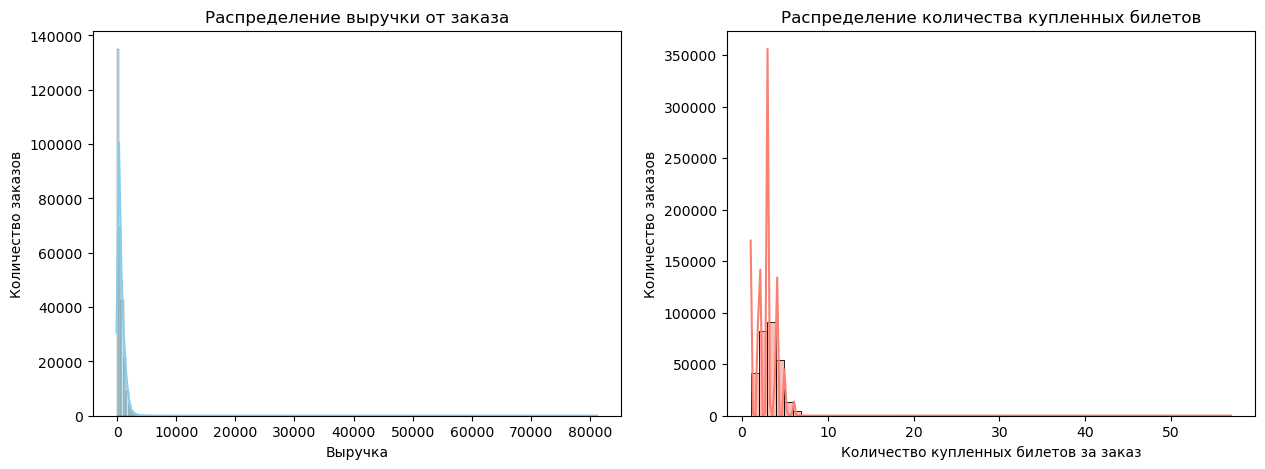

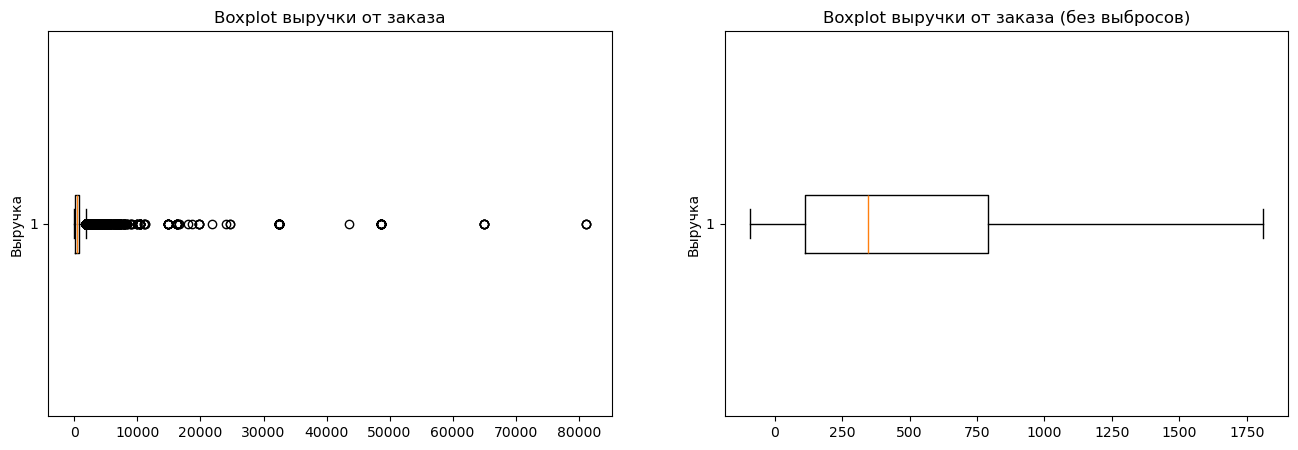

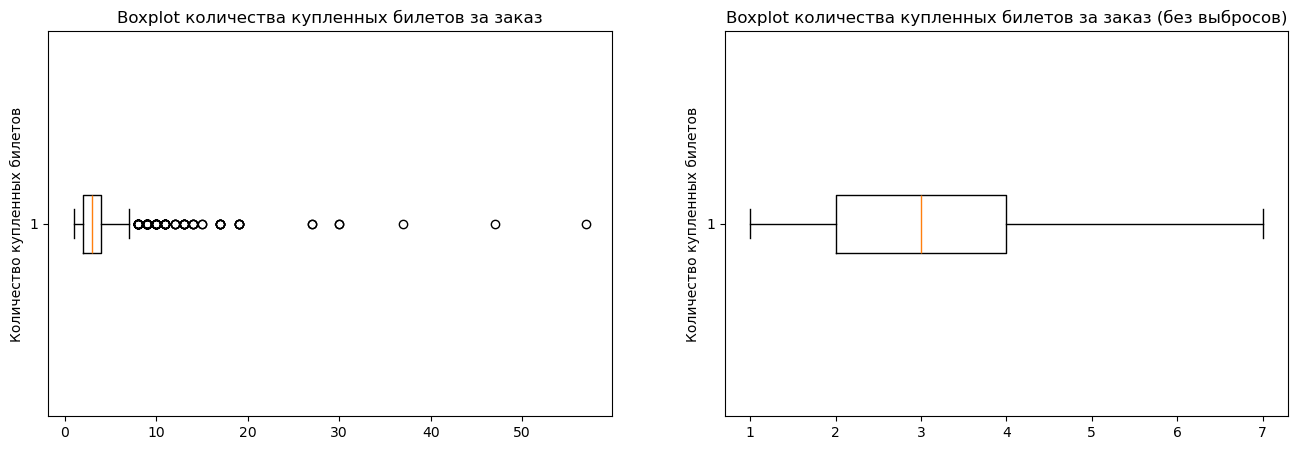

In [6]:
# Общий заголовок
display(Markdown('**Визуализации распределения для валюты в rub**'))

# Визуализация распределения для выборок
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(rub_df['revenue'], bins = 200, kde=True, color='skyblue')
plt.title('Распределение выручки от заказа')
plt.ylabel('Количество заказов')
plt.xlabel('Выручка')

plt.subplot(1, 2, 2)
sns.histplot(rub_df['tickets_count'], bins = 57, kde=True, color='salmon')
plt.title('Распределение количества купленных билетов')
plt.ylabel('Количество заказов')
plt.xlabel('Количество купленных билетов за заказ')

plt.show()

# Визуализация boxplot для выручки
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.boxplot(rub_df['revenue'], vert = False)
plt.title('Boxplot выручки от заказа')
plt.ylabel('Выручка')

plt.subplot(1, 2, 2)
plt.boxplot(rub_df['revenue'], vert = False, showfliers=False)
plt.title('Boxplot выручки от заказа (без выбросов)')
plt.ylabel('Выручка')

plt.show()

# Визуализация boxplot для количества купленных билетов
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.boxplot(rub_df['tickets_count'], vert = False)
plt.title('Boxplot количества купленных билетов за заказ')
plt.ylabel('Количество купленных билетов')

plt.subplot(1, 2, 2)
plt.boxplot(rub_df['tickets_count'], vert = False, showfliers=False)
plt.title('Boxplot количества купленных билетов за заказ (без выбросов)')
plt.ylabel('Количество купленных билетов')

plt.show()

На визуализации данных в валюте "rub" можем наблюдать большое количество выбросов, как и предполагалось, распределение для выручки правостороннее ассиметричное с большим хвостом, но также кроме выбросов присутствуют и отрицательные значения, что нарушает само понятие выручки. Для количества купленных билетов также наблюдается правосторонняя ассиметрия.
Для дальнейшей работы стоит избавиться от выбросов, ограничив данные 99% и убрать данные с отрицательным значением.

**Визуализации распределения для валюты в kzt**

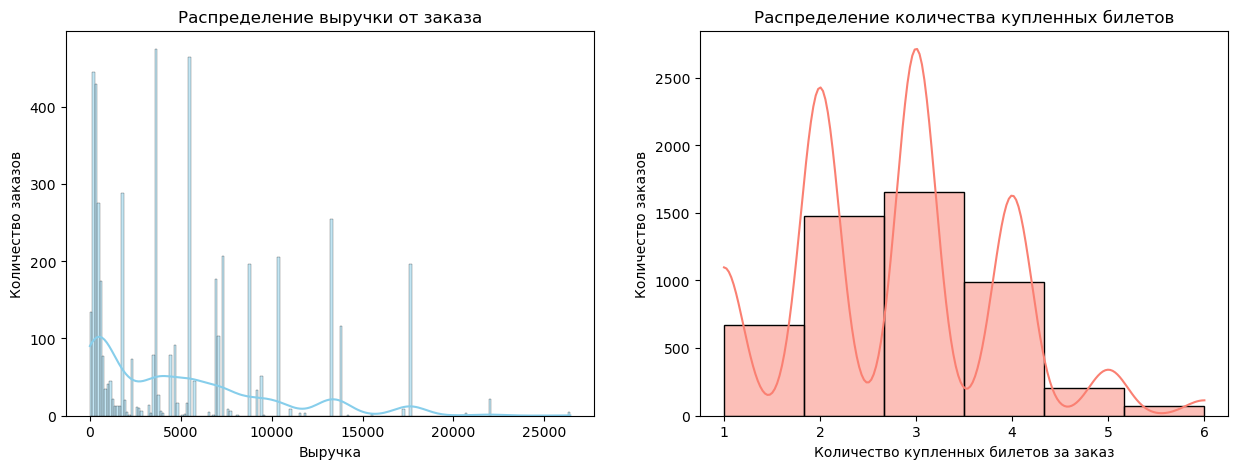

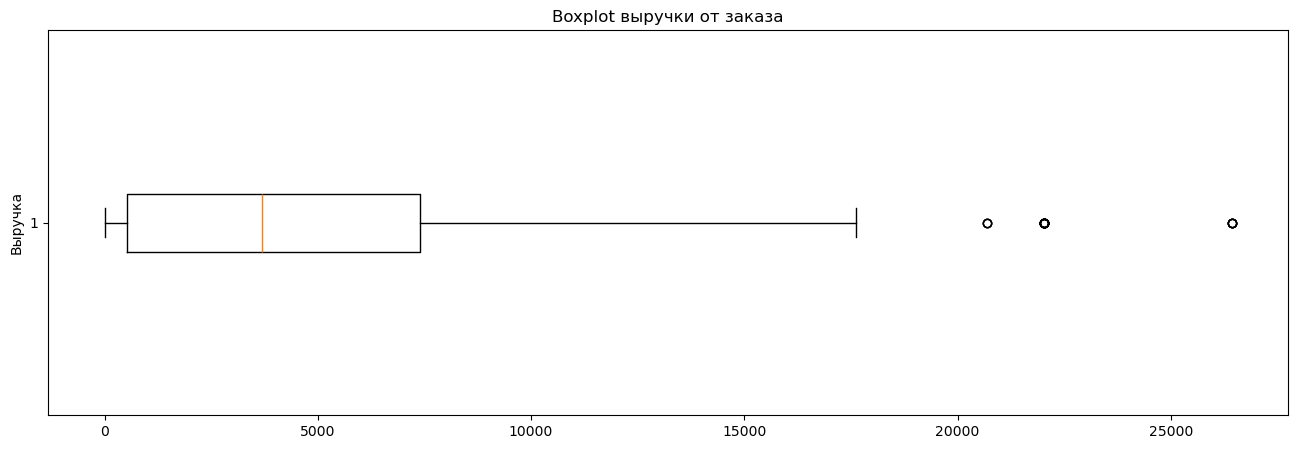

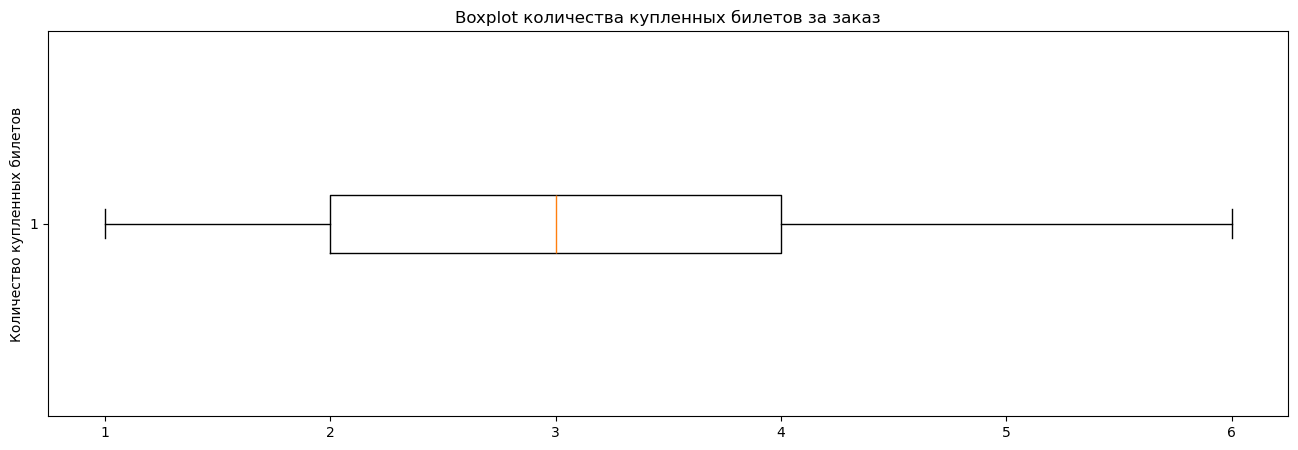

In [7]:
# Общий заголовок
display(Markdown('**Визуализации распределения для валюты в kzt**'))

# Визуализация распределения для выборок
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(kzt_df['revenue'], bins = 200, kde=True, color='skyblue')
plt.title('Распределение выручки от заказа')
plt.ylabel('Количество заказов')
plt.xlabel('Выручка')

plt.subplot(1, 2, 2)
sns.histplot(kzt_df['tickets_count'], bins = 6, kde=True, color='salmon')
plt.title('Распределение количества купленных билетов')
plt.ylabel('Количество заказов')
plt.xlabel('Количество купленных билетов за заказ')

plt.show()

# Визуализация boxplot для выручки
plt.figure(figsize=(16, 5))

plt.boxplot(kzt_df['revenue'], vert = False)
plt.title('Boxplot выручки от заказа')
plt.ylabel('Выручка')

plt.show()

# Визуализация boxplot для количества купленных билетов
plt.figure(figsize=(16, 5))

plt.boxplot(kzt_df['tickets_count'], vert = False)
plt.title('Boxplot количества купленных билетов за заказ')
plt.ylabel('Количество купленных билетов')

plt.show()

На визуализации данных в валюте "kzt" можем наблюдать небольшое количество выбросов в выручке, в данных о количестве купленных билетов они отсутствуют вовсе. Распределение для выручки правостороннее ассиметричное с большим хвостом, данные распределены неравномерно. Для количества купленных билетов также наблюдается правосторонняя ассиметрия.
Для дальнейшей работы стоит избавиться от выбросов, ограничев данные 99% по выручке.

In [8]:
# Расчет 99% для 'revenue' обоих валют и 'tickets_count' для рублей
revenue_rub_percentiles = rub_df['revenue'].quantile(0.99)
tickets_count_rub_percentiles = rub_df['tickets_count'].quantile(0.99)
revenue_kzt_percentiles = kzt_df['revenue'].quantile(0.99)

# Осуществляем фильтрацию данных, убираем ранее расчитанные выбросы более 99% и отрицательные значения
orders_df = orders_df[
    (orders_df['currency_code'] == 'rub')&(orders_df['revenue'] <= revenue_rub_percentiles)
    &(orders_df['revenue'] >= 0)&(orders_df['tickets_count'] <= tickets_count_rub_percentiles)
    |(orders_df['currency_code'] == 'kzt')&(orders_df['revenue'] <= revenue_kzt_percentiles)
]

print(f"Количество оставшихся строк: {orders_df.shape[0]}")
print(f"Метрики по оставшимся после фильтрации данным в рублях")
display(
    (orders_df[orders_df['currency_code'] == 'rub'][['revenue', 'tickets_count']]
         .describe(percentiles = [0.25, 0.5, 0.75, 0.95, 0.99]))
)

print(f"Метрики по оставшимся после фильтрации данным в тенге")
display(
    (orders_df[orders_df['currency_code'] == 'kzt'][['revenue', 'tickets_count']]
         .describe(percentiles = [0.25, 0.5, 0.75, 0.95, 0.99]))
)

Количество оставшихся строк: 287401
Метрики по оставшимся после фильтрации данным в рублях


,revenue,tickets_count
count,282361.000000,282361.000000
mean,510.411296,2.735633
std,499.990515,1.135991
min,0.000000,1.000000
25%,112.350000,2.000000
50%,340.660000,3.000000
75%,781.720000,3.000000
95%,1541.750000,5.000000
99%,2091.310000,6.000000
max,2569.590000,6.000000


Метрики по оставшимся после фильтрации данным в тенге


,revenue,tickets_count
count,5040.000000,5040.000000
mean,4893.669063,2.748413
std,4742.680176,1.101784
min,0.000000,1.000000
25%,515.350000,2.000000
50%,3698.830000,3.000000
75%,7397.660000,3.000000
95%,13784.260000,4.000000
99%,17617.240000,6.000000
max,17617.240000,6.000000


<a id='intro33'></a>
###  [Проверка явных и неявных дубликатов](#intro)

In [9]:
# проверяем количество дубликатов
print(f'Количество явных дубликатов в orders_df: {orders_df.duplicated().sum()}')

# проверяем количество дубликатов
print(f'Количество явных дубликатов в events_df: {events_df.duplicated().sum()}')

# проверяем количество дубликатов
print(f'Количество явных дубликатов в tenge_df: {tenge_df.duplicated().sum()}')

Количество явных дубликатов в orders_df: 0
Количество явных дубликатов в events_df: 0
Количество явных дубликатов в tenge_df: 0


Теперь проверим на неявные идентификаторы, когда:
  1) одинаковый идентификатор, но разное содержание по нему, 
  
  2) разный идентификатор, но одинаковое содержание.

In [10]:
# Проверяем неявные дубликаты (одинаковый идентификатор)
display(Markdown('**Неявные дубликаты когда "Одинаковый идентификатор и разное содержание по нему"**'))

# В датафрейме orders_df
orders = orders_df[['order_id']].duplicated().sum()
print(f'Количество неявных дубликатов в orders_df по ключу: {orders}')

# В датафрейме orders_df
events = events_df[['event_id']].duplicated().sum()
print(f'Количество неявных дубликатов в events_df по ключу: {events}')

# В датафрейме orders_df
tenge = tenge_df[['data']].duplicated().sum()
print(f'Количество неявных дубликатов в tenge_df по ключу: {tenge}')

# Проверяем неявные дубликаты (разный идентификатор)
display(Markdown('**Неявные дубликаты когда "Разный идентификатор и одинаковое содержание"**'))

# В датафрейме orders_df
orders_drop = orders_df.drop(columns='order_id').duplicated().sum()
print(f'Количество неявных дубликатов в orders_df за исключением ключа: {orders_drop}')

# В датафрейме orders_df
events_drop = events_df.drop(columns='event_id').duplicated().sum()
print(f'Количество неявных дубликатов в events_df за исключением ключа: {events_drop}')

# В датафрейме orders_df
tenge_drop = tenge_df.drop(columns='data').duplicated().sum()
print(f'Количество неявных дубликатов в tenge_df за исключением ключа: {tenge_drop}')

**Неявные дубликаты когда "Одинаковый идентификатор и разное содержание по нему"**

Количество неявных дубликатов в orders_df по ключу: 0
Количество неявных дубликатов в events_df по ключу: 0
Количество неявных дубликатов в tenge_df по ключу: 0


**Неявные дубликаты когда "Разный идентификатор и одинаковое содержание"**

Количество неявных дубликатов в orders_df за исключением ключа: 30
Количество неявных дубликатов в events_df за исключением ключа: 871
Количество неявных дубликатов в tenge_df за исключением ключа: 109


Неявные дубликаты были выявлены в датафреймах:
  * events_df: 871, данные дубликаты удалять не цнелесообразно, т.к. иначе при слиянии датафреймов образуются пропуски, но в дальнейшем стоит учитывать, поэтому необходимо создать новый столбец с собственными уникальными кодами ивентов, чтобы использовать в расчетах.
  * tenge_df: 109, в датафрейме всего 4 столбца, 2 из которых содержат одинаковые значения для всех строк, а курс валюты может повторяться, следовательно данные не требуют удаления.

In [11]:
# Создаем новый столбец с уникальными идентификаторами

# Получаем список всех столбцов, кроме 'event_id'
cols_to_group = [col for col in events_df.columns if col != 'event_id']

# Группируем по выбранным столбцам и нумеруем группы, создаем столбец
events_df['unique_event_id'] = events_df.groupby(cols_to_group).ngroup() + 1

Далее проверяем неявные дубликаты в orders_df, обращаем внимание на бронирование билета одним пользователем(user_id) и дополнительными параметрами: в одну дату(created_dt_msk), одинаковой выручкой(revenue) и на одно мероприятие(event_id) с одинаковым количеством билетов(tickets_count) по бронированию билета без учёта идентификаторов заказа.

In [12]:
# Проверяем неявные дубликаты по столбцам 'user_id', 'created_dt_msk', 'revenue','event_id', 'tickets_count'
# Подсчитываем количество и выводим
aa = orders_df[['user_id', 'created_dt_msk', 'revenue','event_id', 'tickets_count']].duplicated().sum()
display(Markdown('**Данные о количестве неявных дубликатов и датафрейм с неявными дубликатами**'))
print(f'Количество неявных дубликатов в orders_df: {aa}')

# Фильтруем и выводим информацию о дублируемых строках для обозрения
duplicates_all = orders_df[orders_df[['user_id', 'created_dt_msk', 'revenue', 
                                      'event_id', 'tickets_count']].duplicated(keep=False)]
display(duplicates_all.sort_values(by = 'order_id').head(20))

# выводим информацию о количестве дубликатов для каждого соответствия
display(Markdown('**Данные о количестве дубликатов по каждому соответствию**'))
display(duplicates_all[['user_id', 'created_dt_msk', 'revenue','event_id', 'tickets_count']].value_counts())

**Данные о количестве неявных дубликатов и датафрейм с неявными дубликатами**

Количество неявных дубликатов в orders_df: 52672


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
87119,1219,3ee7dc2e115847f,2024-10-25,2024-10-25 18:56:02,584025,нет,12,rub,mobile,64.18,Билеты без проблем,4,2139.43,0.0
87118,1277,3ee7dc2e115847f,2024-10-25,2024-10-25 18:54:35,584025,нет,12,rub,mobile,64.18,Билеты без проблем,4,2139.43,0.0
26440,1567,0cef97c91e5e9a8,2024-07-01,2024-07-01 10:37:33,535440,нет,18,rub,mobile,1117.60,Дом культуры,3,15965.71,1.0
26441,1625,0cef97c91e5e9a8,2024-07-01,2024-07-01 11:02:28,535440,нет,18,rub,mobile,1117.60,Дом культуры,3,15965.71,0.0
104237,1828,4df03e0165eb8fd,2024-09-30,2024-09-30 18:59:20,452991,нет,0,rub,desktop,25.79,Билеты в руки,3,429.78,0.0
104238,1857,4df03e0165eb8fd,2024-09-30,2024-09-30 18:57:30,452991,нет,0,rub,desktop,25.79,Билеты в руки,3,429.78,0.0
27050,1915,0e01006afffde4b,2024-09-10,2024-09-10 21:44:43,523780,нет,0,rub,mobile,387.00,Прачечная,5,3518.14,0.0
27048,1944,0e01006afffde4b,2024-09-10,2024-09-10 21:46:27,523780,нет,0,rub,mobile,387.00,Прачечная,5,3518.14,0.0
27049,2002,0e01006afffde4b,2024-09-10,2024-09-10 21:47:02,523780,нет,0,rub,mobile,387.00,Прачечная,5,3518.14,0.0
177819,2698,9103be7b790235f,2024-09-12,2024-09-12 04:35:34,412637,нет,6,rub,mobile,329.94,Восьмёрка,2,2749.50,0.0


**Данные о количестве дубликатов по каждому соответствию**

user_id          created_dt_msk  revenue  event_id  tickets_count
4226e240b0f7a38  2024-09-03      203.95   428762    3                49
                                 135.97   428762    2                45
dc205401360f3ff  2024-10-26      61.22    574441    2                42
                                 91.83    574441    3                40
8d6c1ff89fac35f  2024-10-31      125.49   589624    3                39
                                                                     ..
53b281ff5fada99  2024-09-03      32.82    564987    2                 2
                 2024-08-31      732.64   505789    3                 2
                 2024-08-30      583.85   532848    2                 2
                 2024-08-24      1276.15  373887    3                 2
fffcd3dde79eb2c  2024-10-27      965.57   33189     4                 2
Name: count, Length: 32806, dtype: int64

 Наблюдаем большое количество неявных дубликатов, при этом вызывает сомнения, что пользователи приобрели 2-4 билета и в этот же день решили приобрести столько же билетов (в совокупности 49 раз). А вот когда пользователь приобрел один билет и решил докупить еще один билет, то это возможно. Стоит проверить пользователя с максимальным количеством одинаковых покупок, а также тех, что покупали 1 билет.


In [13]:
# Выведем информацию о пользователе
display(Markdown('**Данные о пользователе с 49 повторяющимися заказами**'))
df_user = orders_df[orders_df['user_id'] == '4226e240b0f7a38']
display(df_user.sort_values(by = 'created_ts_msk').head(50))

#Отфильтруем инфориацию о пользователях, покупающих только 1 билет
df_1 = orders_df[orders_df['tickets_count'] == 1]

# Подсчитываем количество и выводим
aa = df_1[['user_id', 'created_dt_msk', 'revenue','event_id', 'tickets_count']].duplicated().sum()
display(Markdown('**Данные о пользователях с 1 билетом в заказах**'))
print(f'Количество неявных дубликатов в tenge_df: {aa}')

# Фильтруем и выводим информацию о дублируемых строках для обозрения
duplicates_all = df_1[df_1[['user_id', 'created_dt_msk', 'revenue', 'event_id', 'tickets_count']].duplicated(keep=False)]
duplicates_all.sort_values(by = 'order_id').head(10)

**Данные о пользователе с 49 повторяющимися заказами**

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
90643,8568776,4226e240b0f7a38,2024-09-03,2024-09-03 11:02:57,428762,нет,0,rub,desktop,339.92,Билеты в руки,5,5665.36,0.0
90672,8568109,4226e240b0f7a38,2024-09-03,2024-09-03 11:03:45,428762,нет,0,rub,desktop,339.92,Билеты в руки,5,5665.36,0.0
90702,8566717,4226e240b0f7a38,2024-09-03,2024-09-03 11:04:24,428762,нет,0,rub,desktop,339.92,Билеты в руки,5,5665.36,0.0
90720,8570545,4226e240b0f7a38,2024-09-03,2024-09-03 11:04:50,428762,нет,0,rub,desktop,271.94,Билеты в руки,4,4532.29,0.0
90598,8569994,4226e240b0f7a38,2024-09-03,2024-09-03 11:05:33,428762,нет,0,rub,desktop,339.92,Билеты в руки,5,5665.36,0.0
90666,8567181,4226e240b0f7a38,2024-09-03,2024-09-03 11:06:05,428762,нет,0,rub,desktop,339.92,Билеты в руки,5,5665.36,0.0
90688,8571560,4226e240b0f7a38,2024-09-03,2024-09-03 11:06:50,428762,нет,0,rub,desktop,203.95,Билеты в руки,3,3399.22,0.0
90601,8569907,4226e240b0f7a38,2024-09-03,2024-09-03 11:07:32,428762,нет,0,rub,desktop,135.97,Билеты в руки,2,2266.14,0.0
90640,8568950,4226e240b0f7a38,2024-09-03,2024-09-03 11:08:05,428762,нет,0,rub,desktop,271.94,Билеты в руки,4,4532.29,0.0
90684,8571647,4226e240b0f7a38,2024-09-03,2024-09-03 11:09:24,428762,нет,0,rub,desktop,339.92,Билеты в руки,5,5665.36,0.0


**Данные о пользователях с 1 билетом в заказах**

Количество неявных дубликатов в tenge_df: 7497


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
271617,3771,efb8d292edda360,2024-06-19,2024-06-19 19:52:49,498792,нет,12,rub,mobile,543.55,Весь в билетах,1,4941.36,0.0
271618,3858,efb8d292edda360,2024-06-19,2024-06-19 19:29:44,498792,нет,12,rub,mobile,543.55,Весь в билетах,1,4941.36,0.0
271621,3916,efb8d292edda360,2024-06-19,2024-06-19 19:30:21,498792,нет,12,rub,mobile,543.55,Весь в билетах,1,4941.36,0.0
254207,4525,dddfa46f2b72c56,2024-10-17,2024-10-17 19:50:46,502257,нет,16,rub,mobile,62.94,Прачечная,1,629.37,0.0
254210,4612,dddfa46f2b72c56,2024-10-17,2024-10-17 20:48:16,502257,нет,16,rub,mobile,62.94,Прачечная,1,629.37,0.0
254206,4641,dddfa46f2b72c56,2024-10-17,2024-10-17 19:51:10,502257,нет,16,rub,mobile,62.94,Прачечная,1,629.37,0.0
254208,4699,dddfa46f2b72c56,2024-10-17,2024-10-17 20:28:25,502257,нет,16,rub,mobile,62.94,Прачечная,1,629.37,0.0
118579,5772,577516e51315bc2,2024-10-03,2024-10-03 08:56:03,566686,нет,6,rub,mobile,17.16,Лови билет!,1,428.91,26.0
118581,5830,577516e51315bc2,2024-10-03,2024-10-03 08:53:00,566686,нет,6,rub,mobile,17.16,Лови билет!,1,428.91,0.0
240469,6120,cdbc02c6ad8087a,2024-09-01,2024-09-01 18:10:58,542912,нет,12,rub,desktop,108.80,Билеты в руки,1,1087.99,0.0


Разница между заказами в несколько минут, также наблюдаются не соответствия в том, что нумерация заказа не соответсвует времени заказа, т.е. время раньше у одного заказа, чем более раннего заказа(8568776 - 2024-09-03 11:02:57, 8568109 - 2024-09-03 11:03:45).

Лучшим решением будет удалить все неявные дубликаты, т.к. больше похоже на сбой программы, т.к. нет достоверной информации о проведенной транзакции. Возможно, придется пожертвовать частью данных, когда пользователи действительно совершали повторный заказ, а также останутся те заказы, которые были произведены в два дня следующих друг за другом.

In [14]:
# Удаляем неявные дубликаты
orders_df.drop_duplicates(subset=['user_id', 'created_dt_msk', 'revenue','event_id', 'tickets_count'], inplace = True)

print(f'Количество оставшихся строк в orders_df: {orders_df.shape[0]}')

Количество оставшихся строк в orders_df: 234729


<a id='intro33'></a>
### [Объединение датафреймов](#intro)
Для дальнейшей работы объединим датафреймы и подсчитаем вес

In [15]:
# Осуществляем присоединение к orders_df данных из event_id и из tenge_df
df = (
    orders_df.merge(events_df, on = 'event_id', how = 'left')
      .merge(tenge_df, left_on = 'created_dt_msk', right_on = 'data', how = 'left')
     )
# Осуществляем удаление дублирующего столбца data
df = df.drop(columns = 'data')

# Выводим все столбцы
pd.set_option('display.max_columns', None) 

display(Markdown('**Объединенный датафрейм из orders_df, event_id и tenge_df**'))
display(df.info(), df.head())

**Объединенный датафрейм из orders_df, event_id и tenge_df**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234729 entries, 0 to 234728
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                234729 non-null  int64  
 1   user_id                 234729 non-null  object 
 2   created_dt_msk          234729 non-null  object 
 3   created_ts_msk          234729 non-null  object 
 4   event_id                234729 non-null  int64  
 5   cinema_circuit          234729 non-null  object 
 6   age_limit               234729 non-null  int64  
 7   currency_code           234729 non-null  object 
 8   device_type_canonical   234729 non-null  object 
 9   revenue                 234729 non-null  float64
 10  service_name            234729 non-null  object 
 11  tickets_count           234729 non-null  int64  
 12  total                   234729 non-null  float64
 13  days_since_prev         213043 non-null  float64
 14  event_name          

None

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,unique_event_id,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",20360.0,100,18.6972,kzt
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",5582.0,100,18.3419,kzt
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",179.0,100,19.6475,kzt
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",4114.0,100,18.5010,kzt
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1436.0,100,19.6648,kzt


In [16]:
# Перед обработкой датафреймов расчитываем вес датафрейма
start_mem = df.memory_usage(deep=True).sum() / 1024**2
print(f"Начальный вес датафрейма orders_df: {start_mem:.2f} MB")

Начальный вес датафрейма orders_df: 360.15 MB


<a id='intro34'></a>
### [Подсчет пропусков](#intro)
Проверим наличие пропусков и осуществим их обработку при наличии.

In [17]:
# создаем функцию для отображения пропусков
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]

    # Форматируем при выводе через Styler
    return (missing_stats.sort_values(by='Кол-во пропусков', ascending=False).style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))

show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
days_since_prev,21686,0.0924
event_name,194,0.0008
event_type_description,194,0.0008
event_type_main,194,0.0008
organizers,194,0.0008
region_name,194,0.0008
city_name,194,0.0008
city_id,194,0.0008
venue_id,194,0.0008
venue_name,194,0.0008


После объединения появились пустые значения в столбцах. Кроме пустых значений в "days_since_prev" все остальные строки с пропусками удаляем, чтобы не мешали дальнейшей обработке.

In [18]:
# удаляем пустые строки, кроме в столбце 'days_since_prev' 
df = df.dropna(subset=['event_name', 'event_name', 'event_type_description', 
                       'event_type_main', 'organizers', 'region_name', 'city_name',
                       'city_id', 'venue_id', 'venue_name', 'venue_address']).copy()

<a id='intro35'></a>
###  [Преобразование типов данных](#intro)


Осуществим преобразование данных, преобразуем столбцы, в которых содержится дата к datetime64[ns], некоторые столбцы с типом данных object преобразуем в category, а также у числовых столбцов понизим разряд для экономии места.

In [19]:
# Формируем список столбцов для преобразования данных в datetime64[ns]
columns_date = ['created_dt_msk','created_ts_msk']
# Преобразуем 
for col in columns_date:
    df[col] = pd.to_datetime(df[col])
print(f"Преобразовано {len(columns_date)} столбцов datetime64[ns]")

# Cтолбецы преобразуем в тип данных category
columns_category = ['cinema_circuit', 'age_limit', 'currency_code', 
                    'event_type_description', 'event_type_main']
df[columns_category] = df[columns_category].astype('category')
print(f"Преобразовано {len(columns_category)} столбцов category")

# Определяем список столбцов с типом данных int64 и дополнительно столбцы city_id и venue_id 
columns_int = list(df.select_dtypes(include='int64').columns)+['city_id', 'venue_id']
# Понижаем разряд данных 
for col in columns_int:
    df[col] = pd.to_numeric(df[col], downcast='integer')
print(f"Преобразовано {len(columns_int)} столбцов int64")

# Определяем список столбцов с типом данных float64
columns_float = df.select_dtypes(include='float64').columns
# Понижаем разряд данных 
for col in columns_float:
    df[col] = pd.to_numeric(df[col], downcast='float')
print(f"Преобразовано {len(columns_float)} столбцов float64")



Преобразовано 2 столбцов datetime64[ns]
Преобразовано 5 столбцов category
Преобразовано 6 столбцов int64
Преобразовано 5 столбцов float64


<a id='intro36'></a>
### [Создание новых столбцов](#intro)

Создадим необходимые столбцы для дальнейшей работы:
* `revenue_rub` - столбец с конвертацией тенге в рубли, а если в столбце изначально рубли, то оставляем имеющиеся данные,
* `one_ticket_revenue_rub` - выручка с продажи одного билета на мероприятие,
* `month` - месяц оформления заказа
* `season` - информация о сезонности, включая такие категории, как: 'лето', 'осень'. что касается категорий 'зима'и 'весна', то данные не охватывают эти месяцы.

`days_since_prev_new` - новый столбец с подсчетом количества дней с предыдущего заказа. Было удалено много строк, поэтому стоит осущиствить подсчет по новой, а не использовать имеющиеся данные.

In [20]:
# Создаём столбец revenue_rub
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)
df['total'] = df['total'].where(df['currency_code'] == 'rub', df['total'] * df['curs'] / 100)

# Создаём столбец one_ticket_revenue_rub
df['one_ticket_revenue_rub'] = df['revenue_rub']/df['tickets_count']

# Создаём столбец month
df['month'] = df['created_dt_msk'].dt.month

# Создаём столбец season
df['season'] = 'сезон'

# Обновляем для лета и осени, других месяцев нет в данных
df.loc[df['month'].isin([6, 7, 8]), 'season'] = 'лето'
df.loc[df['month'].isin([9, 10, 11]), 'season'] = 'осень'

In [21]:
# Создадим новый столбец с подсчетом количества дней с прошлой покупки

# Отсортируем данные 
df = df.sort_values(['user_id', 'created_ts_msk'])

# Получим дату предыдущей покупки для каждого пользователя
df['prev_purchase_date'] = df.groupby('user_id')['created_ts_msk'].shift(1)

# Посчитаем разницу в днях. Если покупки не было (purchase_date — NaT), результат будет NaN
df['days_since_prev_new'] = (df['created_ts_msk'] - df['prev_purchase_date']).dt.days

# Осуществим вывод данных для проверки
df[['order_id', 'user_id', 'created_ts_msk', 'prev_purchase_date', 'days_since_prev', 'days_since_prev_new']].head(10)

,order_id,user_id,created_ts_msk,prev_purchase_date,days_since_prev,days_since_prev_new
0,4359165,0002849b70a3ce2,2024-08-20 16:08:03,NaT,NaN,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23 18:36:24,NaT,NaN,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06 13:56:02,2024-07-23 18:36:24,75.0,74.0
3,1139875,000898990054619,2024-07-13 19:40:48,NaT,NaN,NaN
4,972400,000898990054619,2024-10-04 22:33:15,2024-07-13 19:40:48,83.0,83.0
5,2613713,000898990054619,2024-10-23 15:12:00,2024-10-04 22:33:15,19.0,18.0
6,6636941,00096d1f542ab2b,2024-08-15 16:48:48,NaT,NaN,NaN
7,4657981,000a55a418c128c,2024-09-29 19:39:12,NaT,NaN,NaN
8,4657952,000a55a418c128c,2024-10-15 10:29:04,2024-09-29 19:39:12,16.0,15.0
9,6818017,000cf0659a9f40f,2024-06-20 10:35:26,NaT,NaN,NaN


Видим разницу в данных старого столбца days_since_prev и нового days_since_prev_new.

<a id='intro37'></a>
###  [Подсчет данных](#intro)

Рассчитаем сколько столбцов было добавлено, сколько строк удалено, как изменился вес датафрейма.

In [22]:
# # Расчитаем общий конечный вес датафреймов и выведем разницу с начальными данными
end_mem = df.memory_usage(deep=True).sum() / 1024**2
savings = (1 - end_mem / start_mem) * 100

# Подсчитаем количество строк и столбцов датафрейма
end_df_rows = (start_df_rows - df.shape[0])/start_df_rows * 100
end_df_columns = df.shape[1] - start_df_columns


print(f"Начальный вес датафреймов: {start_mem:.2f} MB")
print(f"Финальный вес датафрейма: {end_mem:.2f} MB")
print(f"Экономия памяти: {savings:.1f}%")
print(f"В датафрейме было строк: {start_df_rows}, стало строк: {df.shape[0]}, было удалено {start_df_rows - df.shape[0]} строк({end_df_rows:.2f}%).")
print(f"В датафрейме было столбцов: {start_df_columns}, стало столбцов: {df.shape[1]}, было дабавлено: {end_df_columns}.")

Начальный вес датафреймов: 360.15 MB
Финальный вес датафрейма: 276.69 MB
Экономия памяти: 23.2%
В датафрейме было строк: 290849, стало строк: 234535, было удалено 56314 строк(19.36%).
В датафрейме было столбцов: 14, стало столбцов: 34, было дабавлено: 20.


<a id='intro38'></a>
### [Промежуточные выводы](#intro)

Была произведена комплексная обработка данных и проверены данные на выбросы и нормальное распределение в разрезе валюты. Во время обработки были выявлены выбросы, по результатам анализа которых было принято решение отвильтровать выбросы более 99%, которые искажают данные. 

Кроме того на дальнейшую работу могли бы повлиять выявленные неявные дубликаты, которые проверялись по столбцам 'user_id', 'created_dt_msk', 'revenue','event_id', 'tickets_count' и составили 20% данных, природа данных дубликатов неизвестна, но можно предположить, что образованы были в результате технической ошибки и достоверно проверить с имеющимися данными о том, какой заказ является дубликатом не представляется возможном, в результате чего было принято решение об их удаление.

Также были выявлены мероприятия с категорией "Данные", что также могут искажать данные, т.к. перенимают на себя процент из иных типов категорий данных, но заменить на подходящий тип не представляется возможным в связи с отсутствием информации, поэтому оставим без изменения и удаления.


По итогам были получены данные, в которых:
* удалены образовавшиеся пропуски,
* отфильтрованы выбросы,
* удалены неявные дубликаты,
* произведено преобразование данных,
* создано несколько столбцов для дальнейшего анализа.



<a id='intro4'></a>
## [Исследовательский анализ данных](#intro)


### [Анализ распределения заказов по сегментам и их сезонные изменения](#intro)

На дашборде мы могли наблюдать, увеличение показателей в осенний период, теперь стоит более углубленно проверить изменения в заказах, после обработки данных. Необходимо проверить:
 * общую тенденцию заказов по месяцам,
 * сравнить распределение заказов, пользовательскую активность по сезонам по различным категориям.

#### [Расчет количества заказов по месяцам](#intro)

Расчитаем для каждого месяца количество заказов и визуализируем, чтобы понять как менялось количество заказов с июня по конец октября 2024г.

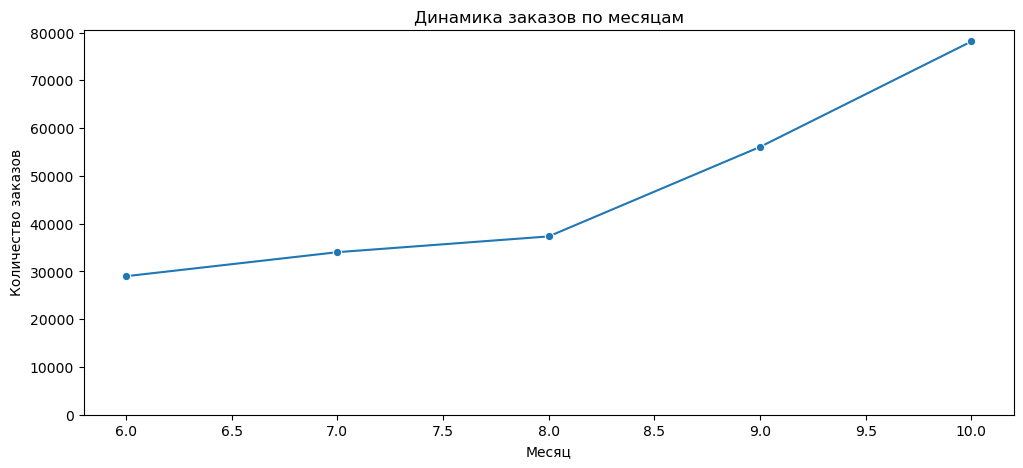

In [23]:
# Группируем данные по месяцам
count_orders_month = df.groupby('month').agg(count_orders = ('order_id', 'count')).reset_index()

# Задаем размер графика
plt.figure(figsize = (12, 5))

# Строим линейный график
sns.lineplot(
    data=count_orders_month, 
    x='month', 
    y='count_orders',
    marker='o'
)

# Настраиваем оформление графика
plt.title('Динамика заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.ylim(0)

plt.show()

На графике наблюдается постепенный рост заказов в летнии месяцы и начиная с сентября происходит резкий скачок в количестве заказов. Это существенная разница между летними и осенними месяцами. Кроме того, стоит обратить внимание, что активность пользователей намного выше осенью при ограниченном наблюдение в течении 2 месяцев, против 3 летних.


<a id='intro412'></a>
#### [Сравнение распределения количества заказов в летний и осенний период](#intro) 


Далее проведем сравнение динамики заказов летом и осенью в распределении по: 
* тип мероприятия `event_type_main`;
* тип устройства `device_type_canonical`;
* категория мероприятий по возрастному рейтингу `age_limit`.

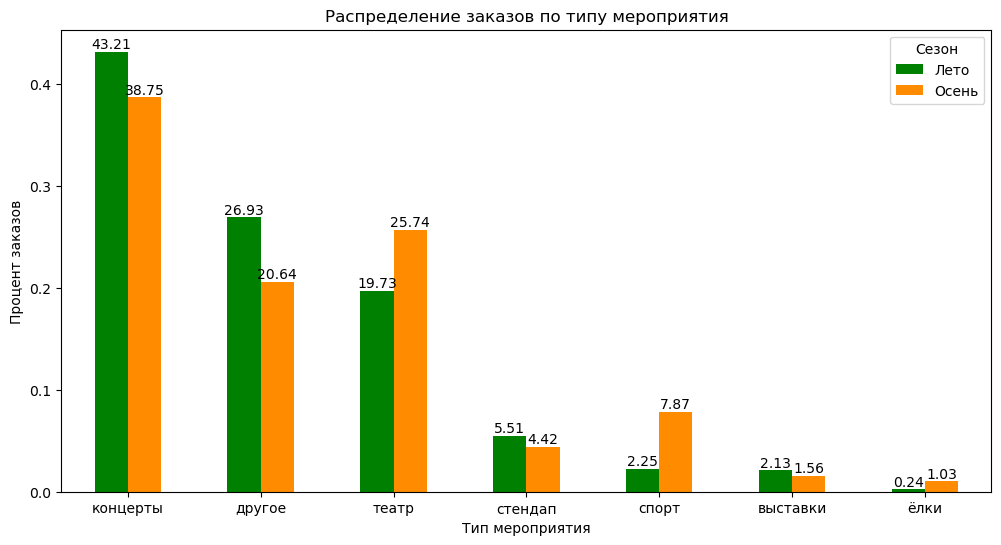

In [24]:
# Группируем данные по сезону и типу мероприятия
count_orders_season_event = df.pivot_table(index = 'event_type_main', 
                                           columns = 'season', 
                                           values = 'order_id', 
                                           aggfunc = 'count',
                                          observed=False
                                          )

# Расчитываем значения в долях
count_orders_season_event['share_summer'] = count_orders_season_event['лето']/(count_orders_season_event['лето'].sum())
count_orders_season_event['share_autumn'] = count_orders_season_event['осень']/(count_orders_season_event['осень'].sum())

# Сортировка по убыванию по значениям в летнем месяце
count_orders_season_event = count_orders_season_event.sort_values(by ='share_summer', ascending = False)

# Строим график
ax = count_orders_season_event[['share_summer', 'share_autumn']].plot(kind = 'bar',
                                                                color=['green', 'darkorange'],
                                                                figsize = (12, 6),
                                                                rot = 0
)

# Подписываем каждую колонку числом сверху
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height, f'{height*100:.2f}', ha='center', va='bottom')

# Настраиваем оформление графика    
plt.title("Распределение заказов по типу мероприятия")
plt.legend(title='Сезон', labels=['Лето', 'Осень'])
plt.xlabel('Тип мероприятия')
plt.ylabel("Процент заказов")

plt.show()

На графике наблюдается, что абсолютным лидером по оформлению заказов остались "Концерты", но осенью пользователи стали предпочитать заказывать билеты и на другие мероприятия, в результате чего спрос на них снизился на 5%, как и на ряд других ранее популярных мероприятий,  а на "Театр", "Спорт" и "Ёлки" увеличился.

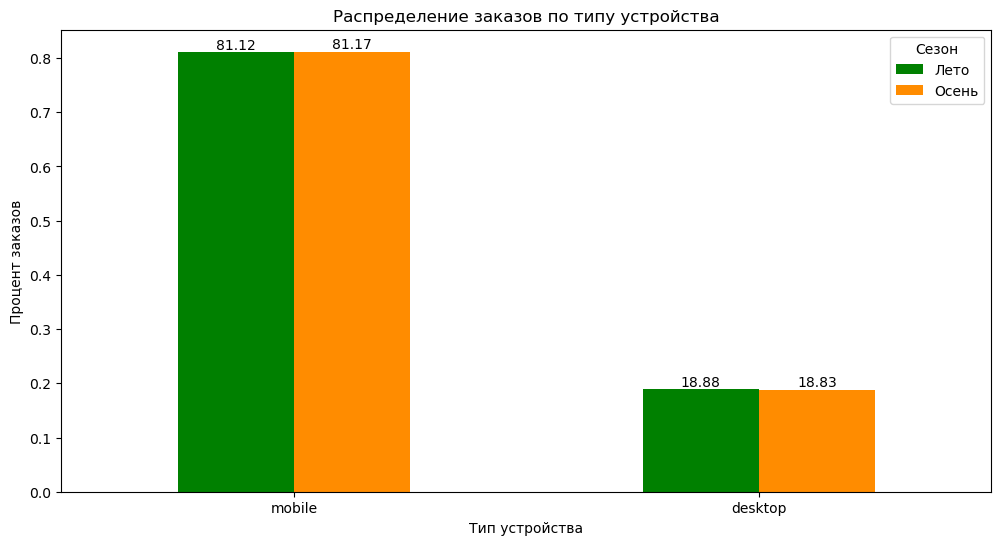

In [25]:
# Группируем данные по сезону и типу мероприятия
count_orders_season_device = df.pivot_table(index = 'device_type_canonical', columns = 'season', values = 'order_id', aggfunc = 'count')

# Расчитываем значения в долях
count_orders_season_device['share_summer'] = count_orders_season_device['лето']/(count_orders_season_device['лето'].sum())
count_orders_season_device['share_autumn'] = count_orders_season_device['осень']/(count_orders_season_device['осень'].sum())

# Сортировка по убыванию по значениям в летнем месяце
count_orders_season_device = count_orders_season_device.sort_values(by ='share_summer', ascending = False)

# Строим график
ax = count_orders_season_device[['share_summer', 'share_autumn']].plot(kind = 'bar',
                                                                color=['green', 'darkorange'],
                                                                figsize = (12, 6),
                                                                rot = 0
)

# Подписываем каждую колонку числом сверху
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height, f'{height*100:.2f}', ha='center', va='bottom')

# Настраиваем оформление графика    
plt.title("Распределение заказов по типу устройства")
plt.legend(title='Сезон', labels=['Лето', 'Осень'])
plt.xlabel('Тип устройства')
plt.ylabel("Процент заказов")

plt.show()

Что касается типа устройств, то здесь сохраняются предпочтения пользователей использовать мобильные устройства для заказа билетов. Изменений между летним периодом и осенним не наблюдается.

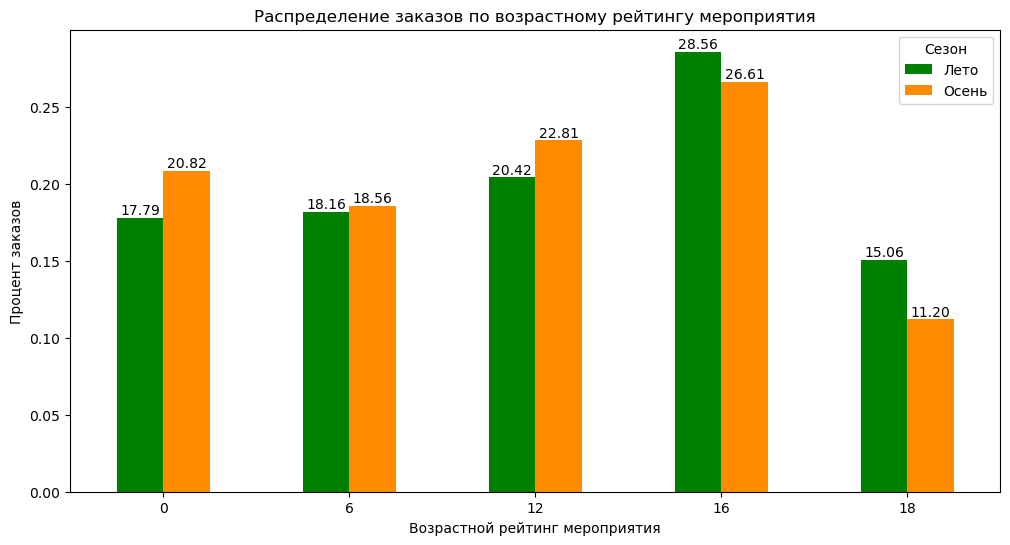

In [26]:
# Группируем данные по сезону и типу мероприятия
count_orders_season_age = df.pivot_table(index = 'age_limit',
                                         columns = 'season',
                                         values = 'order_id', 
                                         aggfunc = 'count',
                                        observed=False
                                        )

# Расчитываем значения в долях
count_orders_season_age['share_summer'] = count_orders_season_age['лето']/(count_orders_season_age['лето'].sum())
count_orders_season_age['share_autumn'] = count_orders_season_age['осень']/(count_orders_season_age['осень'].sum())


# Строим график
ax = count_orders_season_age[['share_summer', 'share_autumn']].plot(kind = 'bar',
                                                                color=['green', 'darkorange'],
                                                                figsize = (12, 6),
                                                                rot = 0
)

# Подписываем каждую колонку числом сверху
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height, f'{height*100:.2f}', ha='center', va='bottom')

# Настраиваем оформление графика    
plt.title("Распределение заказов по возрастному рейтингу мероприятия")
plt.legend(title='Сезон', labels=['Лето', 'Осень'])
plt.xlabel('Возрастной рейтинг мероприятия')
plt.ylabel("Процент заказов")

plt.show()

На графике видны изменения между летним и осенним периодом относительно рейтинга 16+ и 18+, приобретение билетов на данные мероприятия снизились. Это может быть связано с тем, что лето пора каникул и отпусков, в это время взрослые и студенты посещают больше мероприятий в то время, как дети до 16 лет могут находиться в летних лагерях. В осенний же период статистика меняется, в этот период, так же школы и детсады могут организовывать выездные мероприятия для детей до 16 лет. 

<a id='intro413'></a>
#### [Анализ изменения выручки с продажи одного билета](#intro)

Ранее проанализировали динамику изменения количества заказов в разрезе типов мероприятий, теперь необходимо проанализировать изменение выручки с продажи одного билета в зависимости от типа мероприятия летом и осенью.

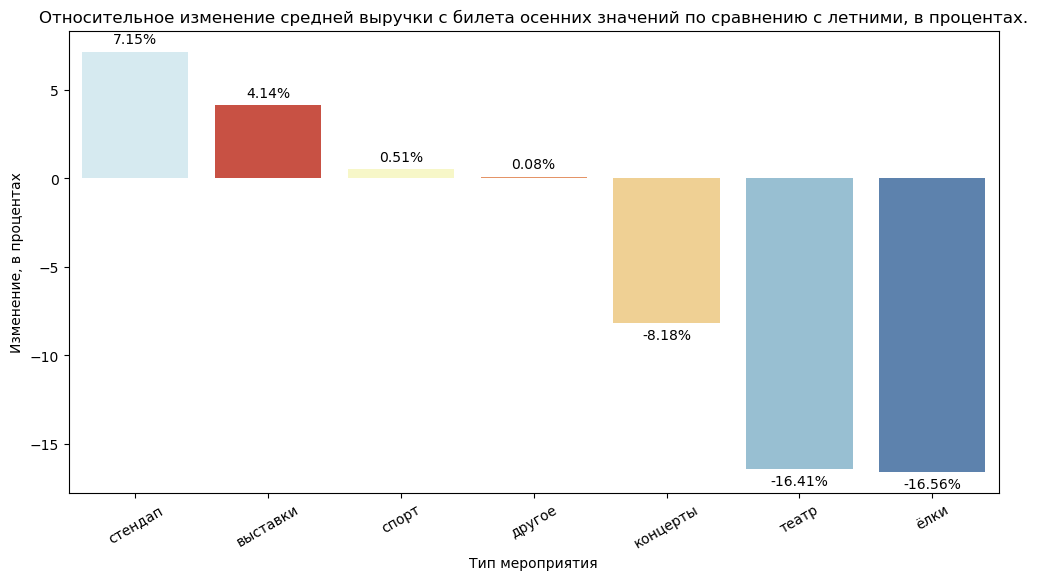

In [27]:
# Группируем данные по сезону и типу мероприятия
pivot = df.pivot_table(
    index = 'event_type_main', 
    columns = 'season', 
    values = ['revenue_rub', 'tickets_count'], 
    aggfunc = 'sum',
    observed=False
).reset_index()

# Расчитываем среднюю выручку с продажи одного билета
pivot['one_ticket_revenue', 'лето'] = pivot['revenue_rub',  'лето']/pivot['tickets_count',  'лето']
pivot['one_ticket_revenue', 'осень'] = pivot['revenue_rub', 'осень']/pivot['tickets_count', 'осень']

# Расчитываем значения в долях
pivot['relative_change_percent'] = (
    (pivot['one_ticket_revenue', 'осень'] - pivot['one_ticket_revenue', 'лето']) 
    / pivot['one_ticket_revenue', 'лето'] * 100
)


# Получаем список категорий в порядке возрастания значений 'relative_change_percent'
order_list = pivot.sort_values('relative_change_percent', ascending = False)['event_type_main'].tolist()

# Строим график с явным указанием порядка столбцов
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=pivot,
    x='event_type_main',
    y='relative_change_percent',
    order=order_list,  # задаём порядок столбцов
    palette='RdYlBu',
    hue='event_type_main'
)

# Подписываем каждую колонку числом сверху/снизу
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2, 
            height + 0.3,
            f'{height:.2f}%',
            ha='center',
            va='bottom'
        )
    else:
        ax.text(
            p.get_x() + p.get_width() / 2, 
            height - 0.3,
            f'{height:.2f}%',
            ha='center',
            va='top'
        )

# Настраиваем оформление графика
plt.title('Относительное изменение средней выручки с билета осенних значений по сравнению с летними, в процентах.')
plt.ylabel('Изменение, в процентах')
plt.xlabel('Тип мероприятия')
plt.xticks(rotation=30)

plt.show()

Наблюдается, что на некотрые мероприятия средняя выручка возрасла, но в большей степени наблюдается динамика снижения средней выручки за билет осенью по сравнению с летом, особенно большое снижение средней выручки за билет на концерты, ёлки и театр. При этом если вернуться к графику "Распределение заказов по типу мероприятия", то количество заказов билетов на мероприятия Театр и ёлки, наоборот возросло, а это значит, что изменения в средней выручке за билет связано либо с понижением стоимости мероприятий, либо пользователи стали выбирать более дешевые события в рамках типа мероприятий, что подтверждает теорию о том, что стало больше пользователей младше возрастом, т.к. у них ограничен бюджет и они предпочитают иные виды развлечений.

<a id='intro414'></a>
#### [Промежуточные выводы](#intro)

 Наблюдается рост количества заказов с июня до октября включительно, при этом в летнии три месяца рост небольшой с 29 тысяч до 37 тысяч заказов. Осенью количество заказов в сентябре составило 56 тысяч, а в октябре 78 тысяч заказов.
Неизменным осталось использование привычных способов заказов с мобильного и стационарного устройства, процентное соотношение не получило существенных изменений с наступлением осени.
Что касается типа мероприятий и возрастного рейтинга, то в некоторых сегментах произошли изменения, пользователи стали больше ходить на другие мероприятия, с иным возрастным рейтингом, чем в летнее время, в результате чего мы можем видеть изменения в топе. Данные изменения затронули среднюю выручку с билета, в результате у некоторых типов мероприятий стало наблюдаться больше средняя выручка, а у других существенно меньше. При этом уменьшение средней выручки на лидирующих мероприятиях, таких как Театр и Концерты, на 17% и 27% выглядят существенным уменьшением, по сравнению с увеличением на мало популярные мероприятия, такие как стендап, выставки, спорт.

Возможно, изменения связаны с сезонность, что можно будет проверить только при длительном наблюдении, на данном этапе стоит уточнить о проведенных акциях и маркетинговых компаниях. Необходимо углублено изучить, что могло повлиять на увеличение и уменьшение показателей. Увеличенные показатели могут говорить о проведении удачной маркетинговой компании, а вот снижение повод пересмотреть и отказаться от данного направления, если уменьшение не связано с более длительным сроком реализации (снижение средней выручки на данном этапе, для увеличения в будущем).  

<a id='intro42'></a>
### [Осенняя активность пользователей](#intro)

Была выявлена большая активность осенью 2024г. Теперь расмотрим различные показатели по календарным дням и дням недели, для понимания как менялась активность пользователей, на что стоит обратить внимание и исправить для улучшения сервиса.

#### [Анализ динамики изменений по дням](#intro)

Проанализируем динамику изменений по дням для:
* общего числа заказов,
* количества активных пользователей DAU,
* среднего числа заказов на одного пользователя,
* средней выручки за один билет,
* средней стоимости одного билета.

In [28]:
# Группируем данные по дням за осень и создаем столбцы с расчетом общего числа заказов - total_orders,
# количества активных пользователей -DAU, а также средней выручки за один билет - avg_revenue_one_ticket.
group_df = (df[df['season'] == 'осень'].
            groupby('created_dt_msk').agg(
                total_orders = ('order_id', 'count'),
                DAU = ('user_id', 'nunique'),
                avg_revenue_one_ticket = ('revenue_rub', 'mean'),
                sum_total = ('total', 'sum'),
                count_ticket = ('tickets_count', 'sum')
            ))

# Создаем столбец с расчетом среднего числа заказов на одного пользователя
group_df['avg_orders_one_user'] = group_df['total_orders']/group_df['DAU']

# Создаем столбец с расчетом средней стоимости одного билета
group_df['price_one_ticket'] = group_df['sum_total']/group_df['count_ticket']

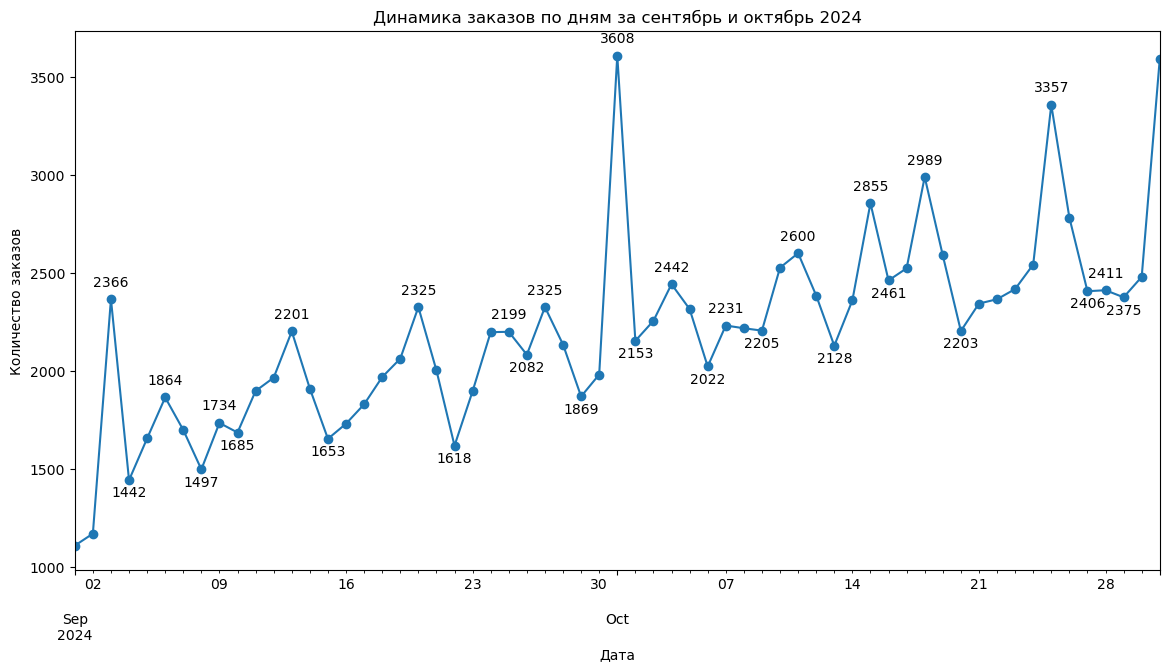

In [29]:
# Задаем размер графика
plt.figure(figsize = (14, 7))

# Строим линейный график
ax = group_df['total_orders'].plot(kind ='line',
                             marker='o'
    )


# Добавляем подписи значений в пиковые и провалы
for i, (x, y) in enumerate(zip(group_df.index, group_df['total_orders'])):
    # Проверяем, что есть и предыдущий, и следующий день (не крайние точки)
    if (i > 0 and i < len(group_df['total_orders']) - 1):
        # Если текущее значение больше и предыдущего, и следующего — это пик
        if (y > group_df['total_orders'].iloc[i-1] and y > group_df['total_orders'].iloc[i+1]):
            ax.text(x, y + 50, f'{y:.0f}', 
                    ha='center', va='bottom', fontsize=10)
        elif (y < group_df['total_orders'].iloc[i-1] and y < group_df['total_orders'].iloc[i+1]):
            ax.text(x, y - 30, f'{y:.0f}', 
                ha='center', va='top', fontsize=10)  # снизу, va='top'

# Настраиваем оформление графика
plt.title('Динамика заказов по дням за сентябрь и октябрь 2024')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')

plt.show()

На графике мы видим колебательно растущую динамику, в основном она наблюдается в пределах определенных значений, при этом постепенно увеличивается. Но также мы видим наиболее большие пики заказов в даты 03.09.2024г, 01.10.2024г. Можно предположить, что в данные дни проходили наиболее популярные мероприятия(либо открывались билеты на эти мероприятия). 

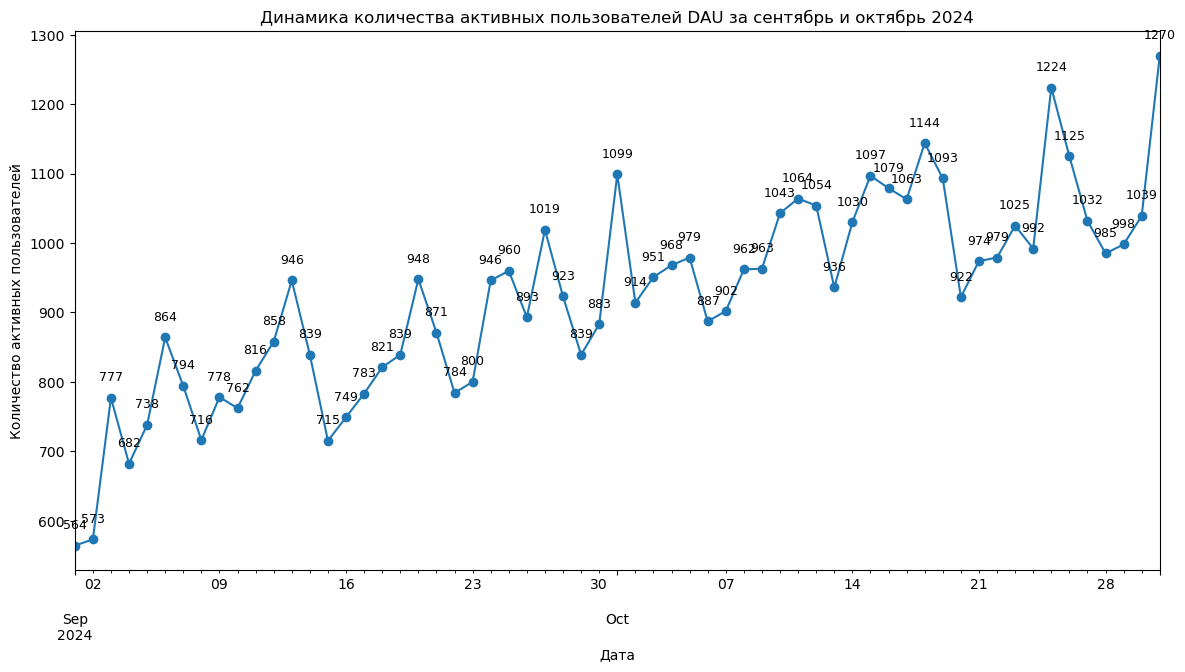

In [30]:
# Задаем размер графика
plt.figure(figsize = (14, 7))

# Строим линейный график
ax = group_df['DAU'].plot(kind ='line',
                             marker='o'
    )


# Добавляем подписи значений 
for i, (date, orders) in enumerate(zip(group_df.index, group_df['DAU'])):
    # i — индекс строки, date — дата, orders — число заказов
    ax.text(date, orders + 20 , f'{orders}', 
            ha='center', va='bottom', fontsize=9)

# Настраиваем оформление графика
plt.title('Динамика количества активных пользователей DAU за сентябрь и октябрь 2024')
plt.xlabel('Дата')
plt.ylabel('Количество активных пользователей')

plt.show()

Динамика количества активных пользователей схожа с динамикой заказов, но без ярко выраженных пиков в даты 03.09.2024г, 01.10.2024г.

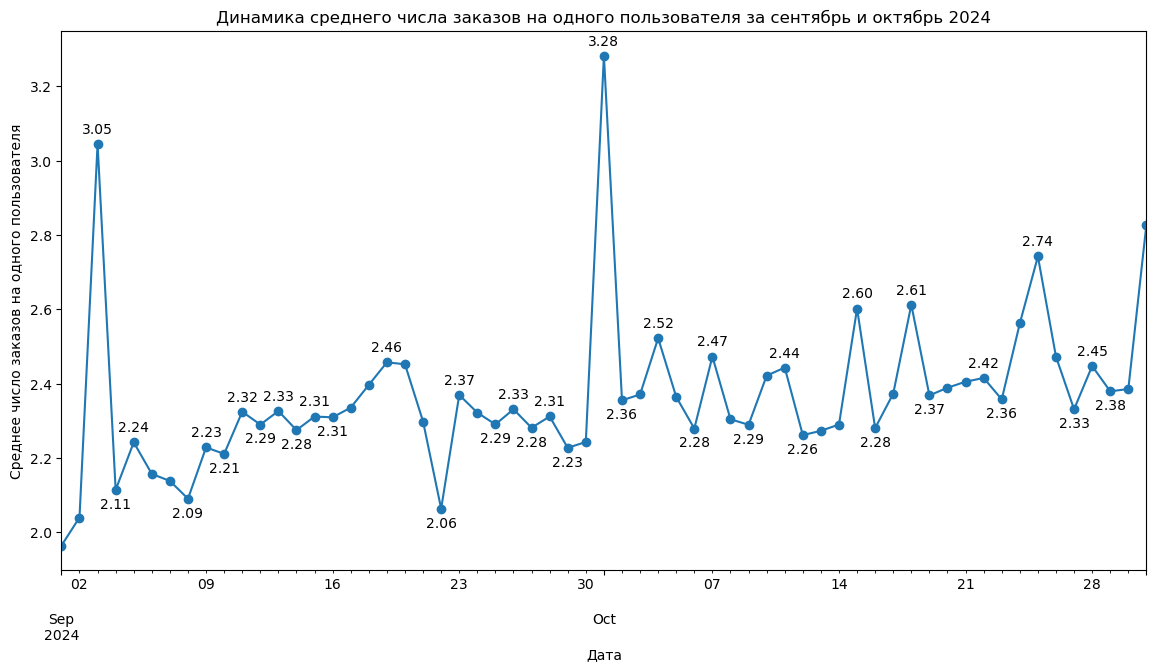

In [31]:
# Задаем размер графика
plt.figure(figsize = (14, 7))

# Строим линейный график
ax = group_df['avg_orders_one_user'].plot(kind ='line',
                             marker='o'
    )


# Добавляем подписи значений в пиковые и провалы
for i, (x, y) in enumerate(zip(group_df.index, group_df['avg_orders_one_user'])):
    # Проверяем, что есть и предыдущий, и следующий день (не крайние точки)
    if (i > 0 and i < len(group_df['avg_orders_one_user']) - 1):
        # Если текущее значение больше и предыдущего, и следующего — это пик
        if (y > group_df['avg_orders_one_user'].iloc[i-1] and y > group_df['avg_orders_one_user'].iloc[i+1]):
            ax.text(x, y + 0.02, f'{y:.2f}', 
                    ha='center', va='bottom', fontsize=10)
        elif (y < group_df['avg_orders_one_user'].iloc[i-1] and y < group_df['avg_orders_one_user'].iloc[i+1]):
            ax.text(x, y - 0.02 , f'{y:.2f}', 
                ha='center', va='top', fontsize=10)  # снизу, va='top'

# Настраиваем оформление графика
plt.title('Динамика среднего числа заказов на одного пользователя за сентябрь и октябрь 2024')
plt.xlabel('Дата')
plt.ylabel('Среднее число заказов на одного пользователя')

plt.show()

Основное количество дней наблюдается стабильное количество пользователей с небольшими колебаниями, но в ранее отмечанные дни также присутствует пик пользователей.

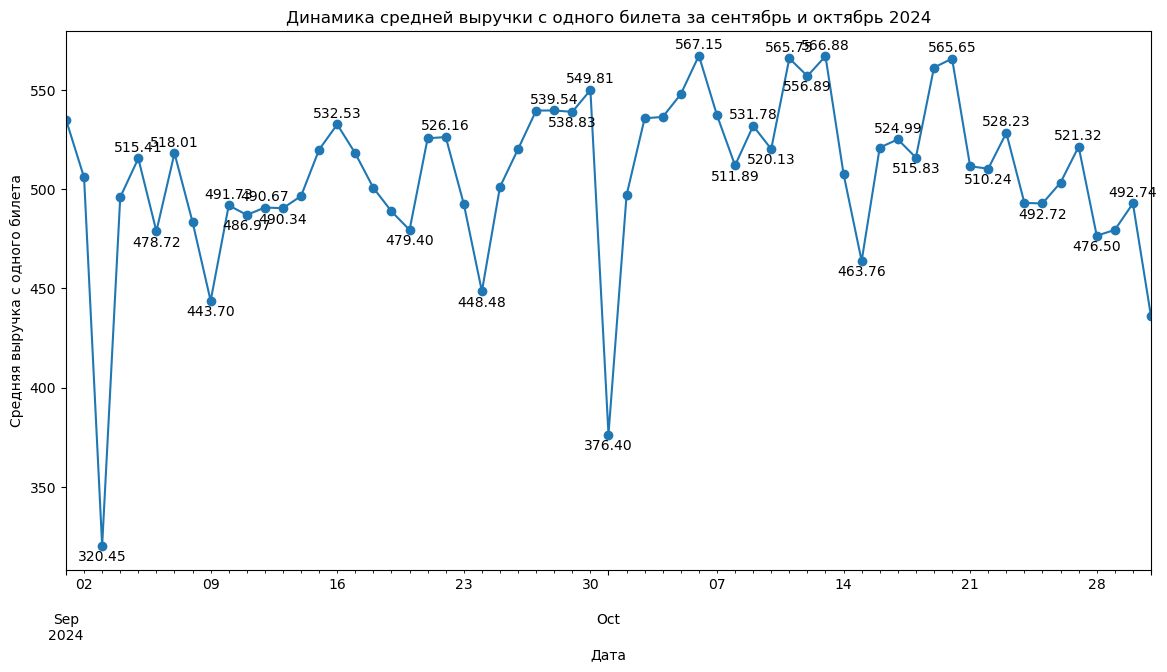

In [32]:
# Задаем размер графика
plt.figure(figsize = (14, 7))

# Строим линейный график
ax = group_df['avg_revenue_one_ticket'].plot(kind ='line',
                             marker='o'
    )


# Добавляем подписи значений в пиковые и провалы
for i, (x, y) in enumerate(zip(group_df.index, group_df['avg_revenue_one_ticket'])):
    # Проверяем, что есть и предыдущий, и следующий день (не крайние точки)
    if (i > 0 and i < len(group_df['avg_revenue_one_ticket']) - 1):
        # Если текущее значение больше и предыдущего, и следующего — это пик
        if (y > group_df['avg_revenue_one_ticket'].iloc[i-1] and y > group_df['avg_revenue_one_ticket'].iloc[i+1]):
            ax.text(x, y + 2, f'{y:.2f}', 
                    ha='center', va='bottom', fontsize=10)
        elif (y < group_df['avg_revenue_one_ticket'].iloc[i-1] and y < group_df['avg_revenue_one_ticket'].iloc[i+1]):
            ax.text(x, y - 2 , f'{y:.2f}', 
                ha='center', va='top', fontsize=10)  # снизу, va='top'

# Настраиваем оформление графика
plt.title('Динамика средней выручки с одного билета за сентябрь и октябрь 2024')
plt.xlabel('Дата')
plt.ylabel('Средняя выручка с одного билета')

plt.show()

На данном графике мы видим уже более большие колебания, при этом эти колебания стремятся сначало в сторону увелечения, а потом в сторону резкого спада средней выручки. 03.09.2024г и 01.10.2024г наблюдаются самые большие провалы.

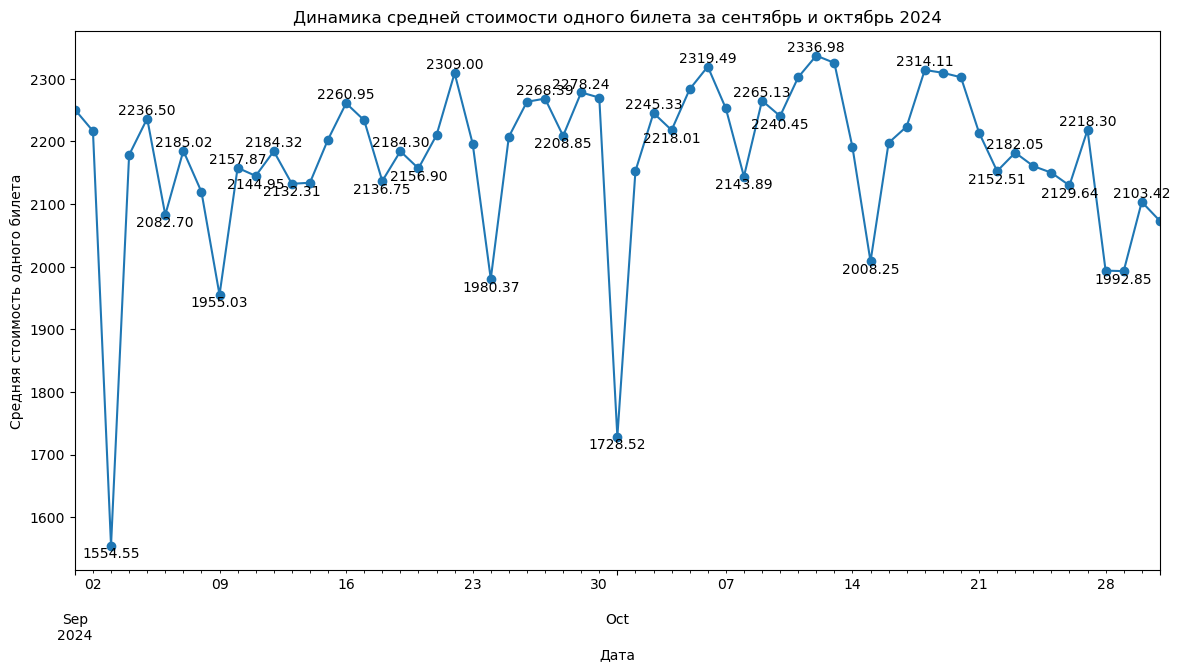

In [33]:
# Задаем размер графика
plt.figure(figsize = (14, 7))

# Строим линейный график
ax = group_df['price_one_ticket'].plot(kind ='line',
                             marker='o'
    )


# Добавляем подписи значений в пиковые и провалы
for i, (x, y) in enumerate(zip(group_df.index, group_df['price_one_ticket'])):
    # Проверяем, что есть и предыдущий, и следующий день (не крайние точки)
    if (i > 0 and i < len(group_df['price_one_ticket']) - 1):
        # Если текущее значение больше и предыдущего, и следующего — это пик
        if (y > group_df['price_one_ticket'].iloc[i-1] and y > group_df['price_one_ticket'].iloc[i+1]):
            ax.text(x, y + 2, f'{y:.2f}', 
                    ha='center', va='bottom', fontsize=10)
        elif (y < group_df['price_one_ticket'].iloc[i-1] and y < group_df['price_one_ticket'].iloc[i+1]):
            ax.text(x, y - 2 , f'{y:.2f}', 
                ha='center', va='top', fontsize=10)  # снизу, va='top'

# Настраиваем оформление графика
plt.title('Динамика средней стоимости одного билета за сентябрь и октябрь 2024')
plt.xlabel('Дата')
plt.ylabel('Средняя стоимость одного билета')

plt.show()

При сравнение двух взаимосвязанных метрик "Средней выручки за один билет" и "Средней стоимости билета", можно наблюдать, что в основном черты изменения показателей на графиках схожи, но имеются и отличия, что может указывать на проведение различных акций и маркетинговых компаний. При увеличении средней стоимости билета, падает выручка с билета и наоборот, это может указывать, на то что на формирование вырочки могли повлиять другие показатели в эти дни(акции на мероприятие, акции для пользователей и т.д.). 


<a id='intro422'></a>
#### [Недельная цикличность](#intro)
Проверим закономерность пользовательской активности в будни и выходные в разрезе среднего количества заказов. Рассмотрим распределение по дням недели и в зависимости от типа дня недели.

In [34]:
# Создадим новый столбец с номером дня недели, где пн-1
df['day_of_week'] = df['created_dt_msk'].dt.day_of_week+1

# Сгруппируем сумарное количество заказов по дате и дню недели, сбросим индекс
group_dt_week = df.groupby(['created_dt_msk', 'day_of_week']).agg(
    count =('order_id', 'count'),
    sum_revenue = ('revenue_rub', 'sum'),
    median_revenue = ('revenue_rub', 'median')
).reset_index()

# Создаем столбец с делением на будний и выходной день
group_dt_week['weekdays_weekends'] = np.where(group_dt_week['day_of_week'] < 6, 'Будний день', 'Выходной день')

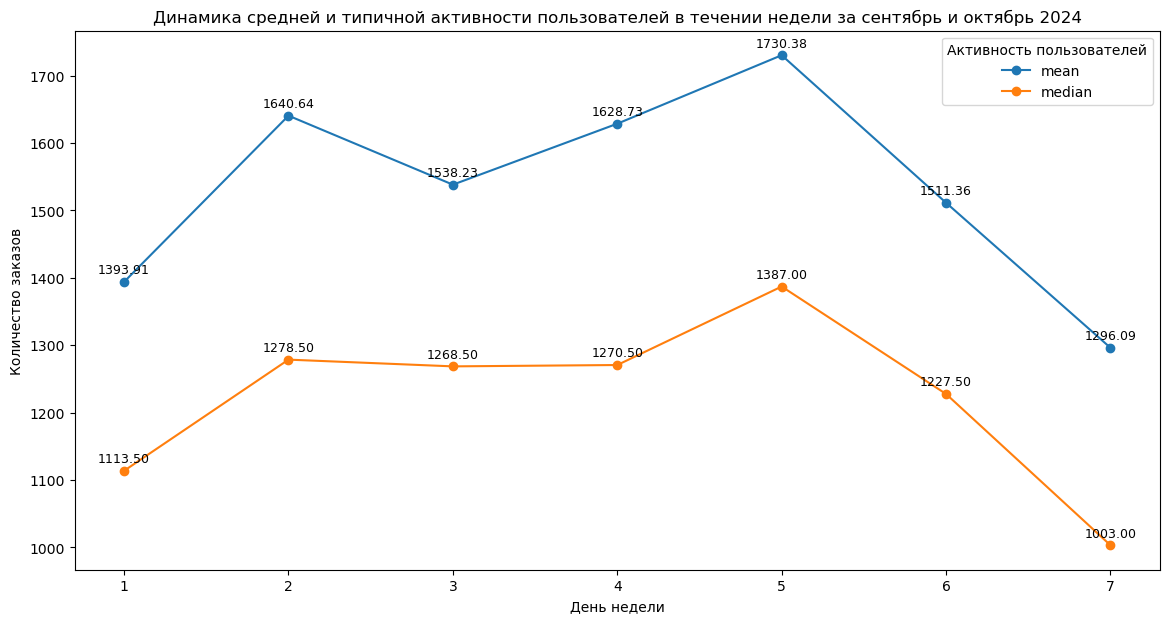

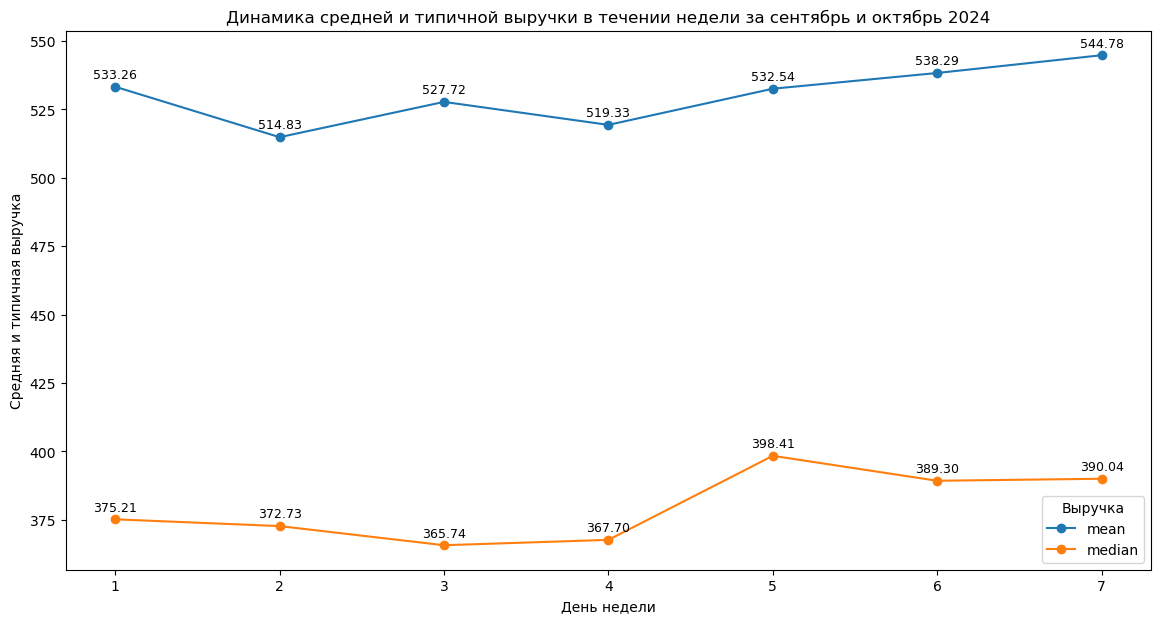

In [35]:
# ДЛЯ ГРАФИКОВ 1-2: ПО ДНЯМ НЕДЕЛИ

# Сгруппируем полученные данные по дню недели и вычислим среднюю и медиану активности для каждого дня
group_week = group_dt_week.groupby('day_of_week').agg(
    avg_users_activity = ('count', 'mean'),
    median_users_activity = ('count', 'median'),
    sum_count =('count', 'sum'), # сумма заказов для расчета средней выручки
    revenue = ('sum_revenue', 'sum'), # сумма выручки для расчета средней
    median = ('median_revenue', 'median') 
)

# Создаем столбец со средней выручкой по дням недели
group_week['avg_revenue'] = group_week['revenue']/group_week['sum_count']

# ---------------------------------------------------------------------------------------------
# Строим график 1
ax = group_week[['avg_users_activity', 'median_users_activity']].plot(
    kind ='line',  
    marker='o', 
    figsize = (14, 7), 
    legend = False
)
 
# Добавляем подписи значений 
for i, (date, mean, median) in enumerate(zip(group_week.index, group_week['avg_users_activity'],
                                             group_week['median_users_activity'])):
    # Подпись для СРЕДНЕГО значения (синяя линия)
    ax.text(date, mean + 8, f'{mean:.2f}', 
            ha='center', va='bottom', fontsize=9)
    
    # Подпись для МЕДИАНЫ (оранжевая линия)
    ax.text(date, median + 8, f'{median:.2f}', 
            ha='center', va='bottom', fontsize=9)

# Настраиваем оформление графика
plt.title('Динамика средней и типичной активности пользователей в течении недели за сентябрь и октябрь 2024')
plt.legend(title='Активность пользователей', labels=['mean', 'median'])
plt.xlabel('День недели')
plt.ylabel('Количество заказов')

plt.show()

# -------------------------------------------------------------------------------------------
# Строим график 2
ax = group_week[['avg_revenue', 'median']].plot(
    kind ='line',  
    marker='o', 
    figsize = (14, 7), 
    legend = False
)

# Добавляем подписи значений 
for i, (date, mean, median) in enumerate(zip(group_week.index, group_week['avg_revenue'],
                                             group_week['median'])):
    # Подпись для СРЕДНЕГО значения (синяя линия)
    ax.text(date, mean + 2, f'{mean:.2f}', 
            ha='center', va='bottom', fontsize=9)
    
    # Подпись для МЕДИАНЫ (оранжевая линия)
    ax.text(date, median + 2, f'{median:.2f}', 
            ha='center', va='bottom', fontsize=9)

# Настраиваем оформление графика
plt.title('Динамика средней и типичной выручки в течении недели за сентябрь и октябрь 2024')
plt.legend(title='Выручка', labels=['mean', 'median'])
plt.xlabel('День недели')
plt.ylabel('Средняя и типичная выручка')

plt.show()

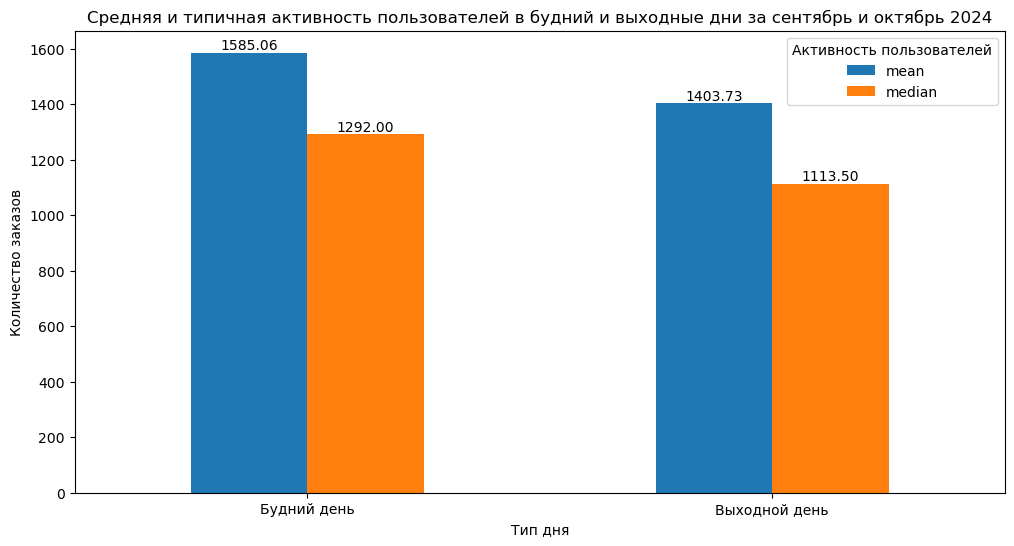

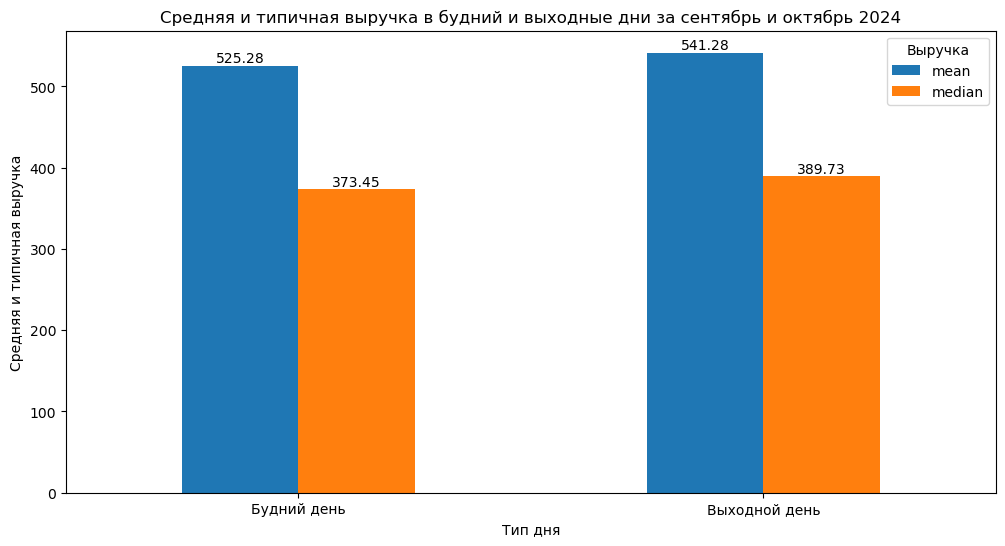

In [36]:
# ДЛЯ ГРАФИКОВ 3-4: ПО БУДНИМ/ВЫХОДНЫМ
# Сгруппируем полученные данные по будним/выходным и вычислим среднюю и медиану активности для каждой категории
group_ww = group_dt_week.groupby('weekdays_weekends').agg(
    avg_users_activity = ('count', 'mean'),
    median_users_activity = ('count', 'median'),
    sum_count =('count', 'sum'), # сумма заказов для расчета средней выручки
    revenue = ('sum_revenue', 'sum'), # сумма выручки для расчета средней и медианной выручки
    median = ('median_revenue', 'median')
)

# Создаем столбец со средней выручкой по дням недели
group_ww['avg_revenue'] = group_ww['revenue']/group_ww['sum_count']

# ---------------------------------------------------------------------------------------------
# Строим график 3
ax = group_ww[['avg_users_activity', 'median_users_activity']].plot(
    kind = 'bar', 
    figsize = (12, 6),
    rot = 0
)

# Подписываем каждую колонку числом сверху
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom')

# Настраиваем оформление графика    
plt.title("Средняя и типичная активность пользователей в будний и выходные дни за сентябрь и октябрь 2024")
plt.legend(title='Активность пользователей', labels=['mean', 'median'])
plt.xlabel('Тип дня')
plt.ylabel("Количество заказов")

plt.show()

# ---------------------------------------------------------------------------------------------
# Строим график 4
ax = group_ww[['avg_revenue', 'median']].plot(
    kind = 'bar', 
    figsize = (12, 6),
    rot = 0
)

# Подписываем каждую колонку числом сверху
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom')

# Настраиваем оформление графика    
plt.title("Средняя и типичная выручка в будний и выходные дни за сентябрь и октябрь 2024")
plt.legend(title='Выручка', labels=['mean', 'median'])
plt.xlabel('Тип дня')
plt.ylabel("Средняя и типичная выручка")

plt.show()

Средняя и медианная активность пользователей по количеству заказав выше в буднии дни, чем в выходные.
Средняя активность, то возрастает, то существенно падает в середине недели и в выходные уже более резко идет на спад достигая минимума. Медиана активности пользователей во многом повторяет среднюю активность, но без существенного уменьшения среди недели. Средняя активность пользователей намного превышает медианные значения, следовательно в какие то дни встречаются выбросы, когда проводились регулярные популярные мероприятия. 

</font><font color='Blue'><b> Медианное значение выручки уже так не повторяет среднеее значение, как на прошлом графике. Мы видим отличия, что средняя и медианная выручка наоборот возрастает с пятницы по воскресение, при этом колебания не настолько существенные в течении недели и составляют 30руб. 
    
Невзирая на общий спад пользователей в выходные средняя и медианная выручка становится выше.</b></font><br>

<a id='intro423'></a>
#### [Промежуточные выводы](#intro)

По итогу можно предположить, что 03.09.2024г и 01.10.2024г проходили(или было открытие продажи билетов) довольно популярные мероприятия, при этом средняя выручка, получаемая с этих мероприятий ниже, чем обычно. В остальном колебания в данных о "Динамике заказов по дням", "DAU" и "Динамике среднего числа заказов на одного пользователя" нормальные и цикличные с постепенным повышением, а колебания зависят от дня недели, что мы и видим на графике "Динамики средней активности пользователя в течении недели...", где есть дни когда средняя активность выше - пятница, и где резко падает ниже обычной в течении недели - в воскресенье, </font><font color='Blue'><b> а средняя и типичная выручка наоборот возрастает</b></font><br>. Динамика средней выручки с одного билета демонстрирует высокую изменчивость, с частыми резкими подъемами и спадами.

</font><font color='Blue'><b> Стоит рассмотреть способы повышения активности пользователей в выходные дни, при этом избежать падение средней выручки.</b></font><br>

<a id='intro43'></a>
### [Популярные события и партнёры](#intro)

#### [Проверка распределения событий по регионам и партнерам](#intro)


Тепрь более детально проанализируем регионы и билетных партнеров, выявим возможные точки роста.

In [37]:
# Создаем пользовательскую функцию для построения графика столбчатой диаграммы
def plot_top10_bar(df, column, title, x_label, y_label):
    """
    Строит столбчатую диаграмму топ 10 по метрике и ее доле.
    
    Параметры:
    df — датафрейм с данными;
    column - название столбца с метрикой;
    title — заголовок графика;
    x_label — подпись оси X;
    y_label — подпись оси Y.
    """
    # 1. Создаем столбец с пропорцией
    df_copy = df.copy()
    
    # 2. Создаем столбец с пропорцией
    df_copy['proportion'] = round(df_copy[column]/(df_copy[column].sum())*100, 2)
    
    # 3. Добавляем столбец для надписей
    df_copy['column_signature'] = (df_copy[column].astype('str') + ' (' 
                                        + df_copy['proportion'].astype('str') +'%)')
    
    # 4. Сортируем и оставляем топ 10 
    df_copy = (
        df_copy.sort_values(by = column, ascending = False)
        .head(10))
    
    df_copy = df_copy.sort_values(by = column, ascending = True)
    
    # 5. Строим столбчатую диаграмму с помощью pandas через plot(kind='barh')
    ax = df_copy[column].plot(
        kind='barh',
        rot=0,
        legend=False, 
        figsize=(14, 7)
    )
    # 6. Добавляем подписи из 'column_proportion'
    for p, label in zip(ax.patches, df_copy['column_signature']):
        width = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.text(width + 0.5, y, label, va='center')
    
    # 7. Высчитываем размер xlim
    right = df_copy[column].max()+df_copy[column].max()*0.17
        
    # 8. Настраиваем оформление графика
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    ax.set_xlim(left=0, right=right)
    
    plt.show()

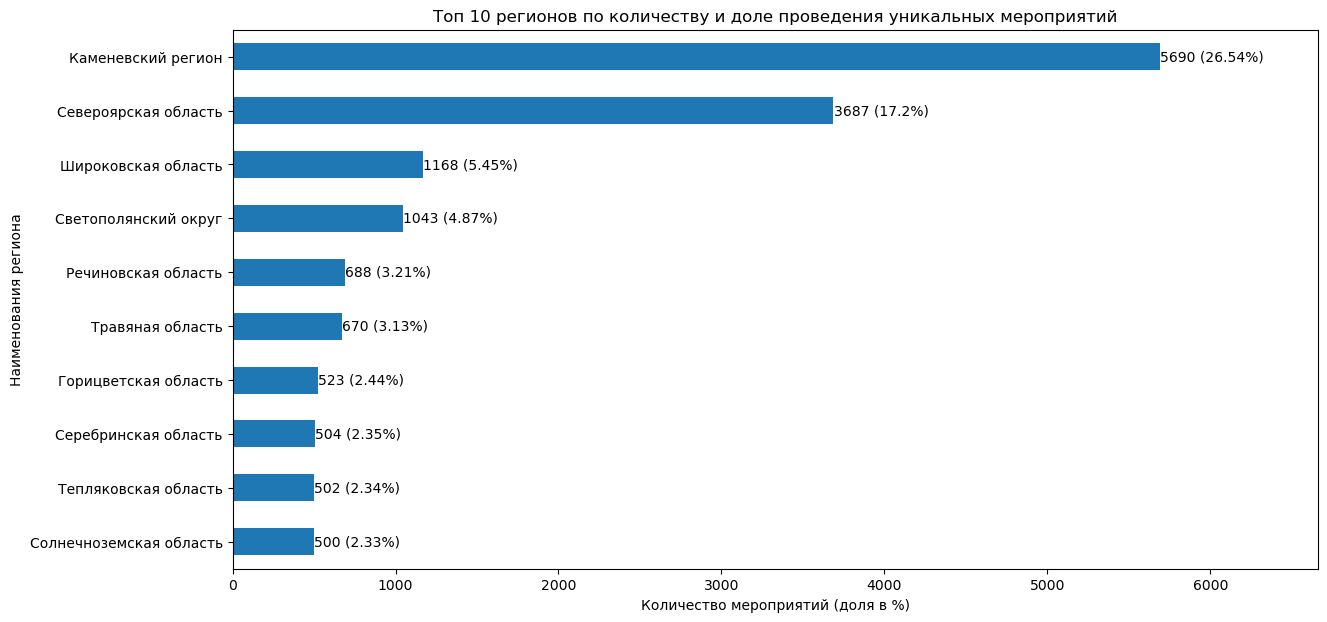

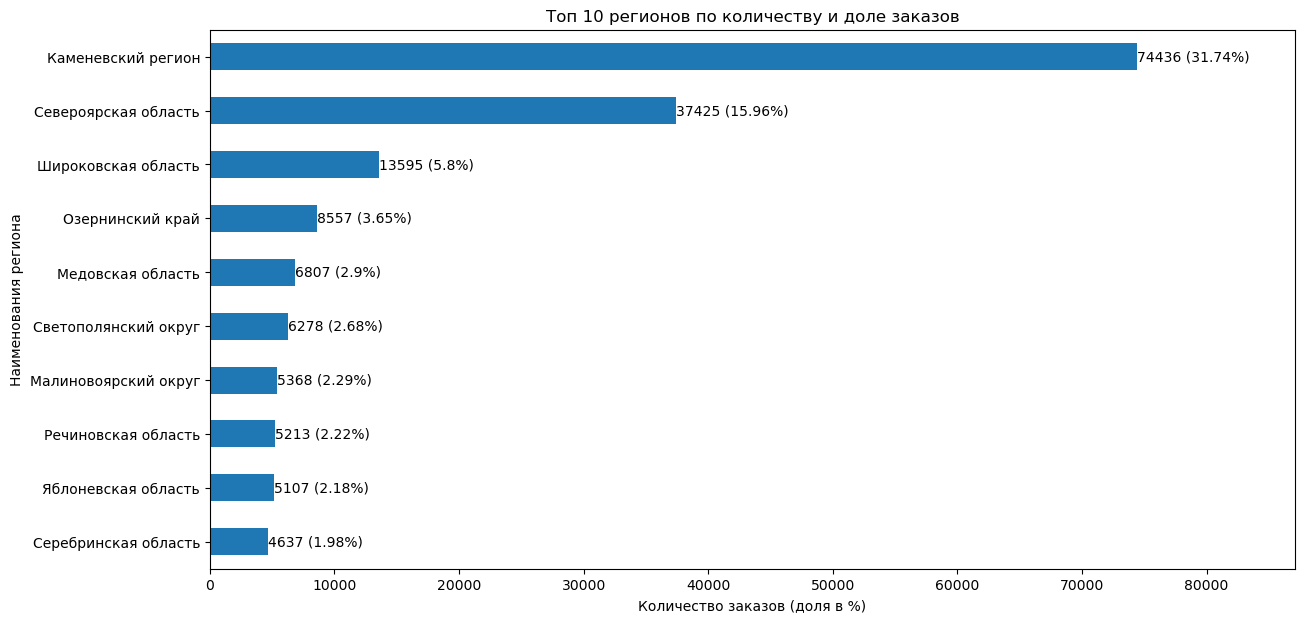

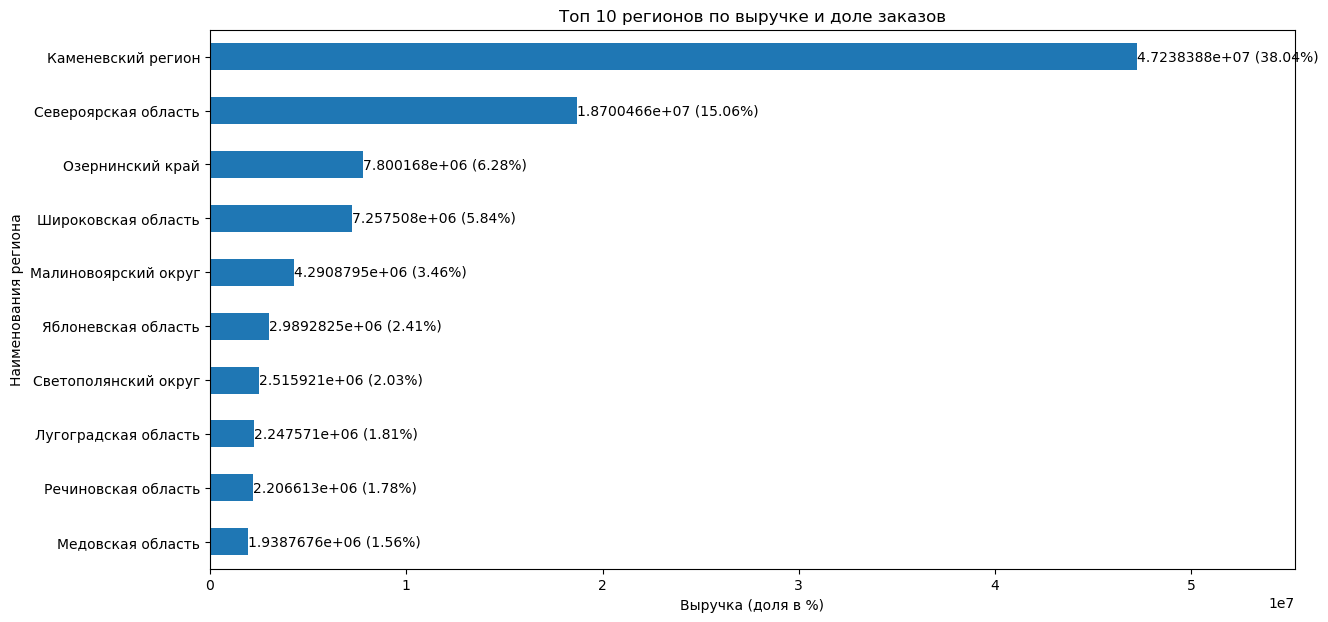

In [38]:
# Групируем уникальные мерроприятия по региону
group_region = df.groupby('region_name').agg(
    count_event = ('unique_event_id', 'nunique'),
    count_orders = ('order_id','count'),
    sum_revenue = ('revenue_rub', 'sum')
)


# Строим график столбчатой диаграммы - Топ 10 регионов по количеству и доле проведения уникальных мероприятий
plot_top10_bar(
    df = group_region,
    column = 'count_event',
    title='Топ 10 регионов по количеству и доле проведения уникальных мероприятий',
    x_label='Количество мероприятий (доля в %)',
    y_label='Наименования региона'
)

# Строим график столбчатой диаграммы - Топ 10 регионов по количеству и доле заказов
plot_top10_bar(
    df = group_region,
    column = 'count_orders',
    title='Топ 10 регионов по количеству и доле заказов',
    x_label='Количество заказов (доля в %)',
    y_label='Наименования региона'
)

# Строим график столбчатой диаграммы - Топ 10 регионов по выручке и доле заказов
plot_top10_bar(
    df = group_region,
    column = 'sum_revenue',
    title='Топ 10 регионов по выручке и доле заказов',
    x_label='Выручка (доля в %)',
    y_label='Наименования региона'
)

На графике топ 10 регионов можно наблюдать, что абсолютным лидером является "Каменевский регион" с 26% в проведении мероприятий, с 32% по количеству заказов, 38% по выручке, далее с большим отставанием от 10 до 23 % идет "Североярская область", после чего идут области с метриками ниже 6%, которые сменяют друг друга, одни метрики выше в одном топе, в другом другие.

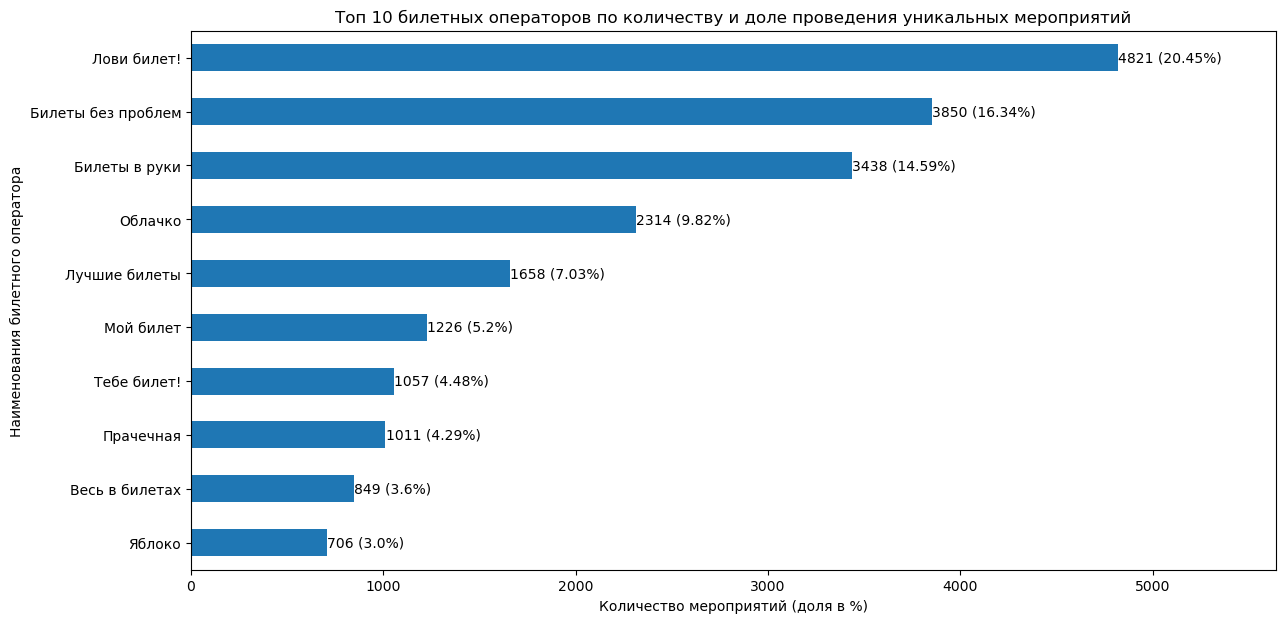

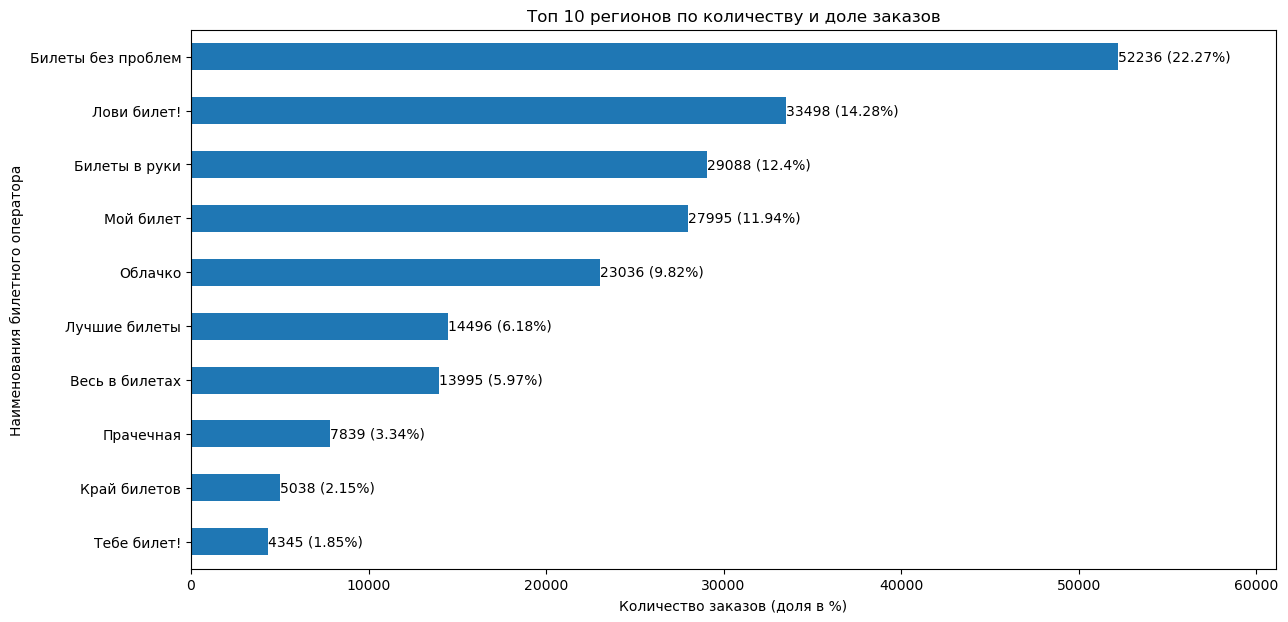

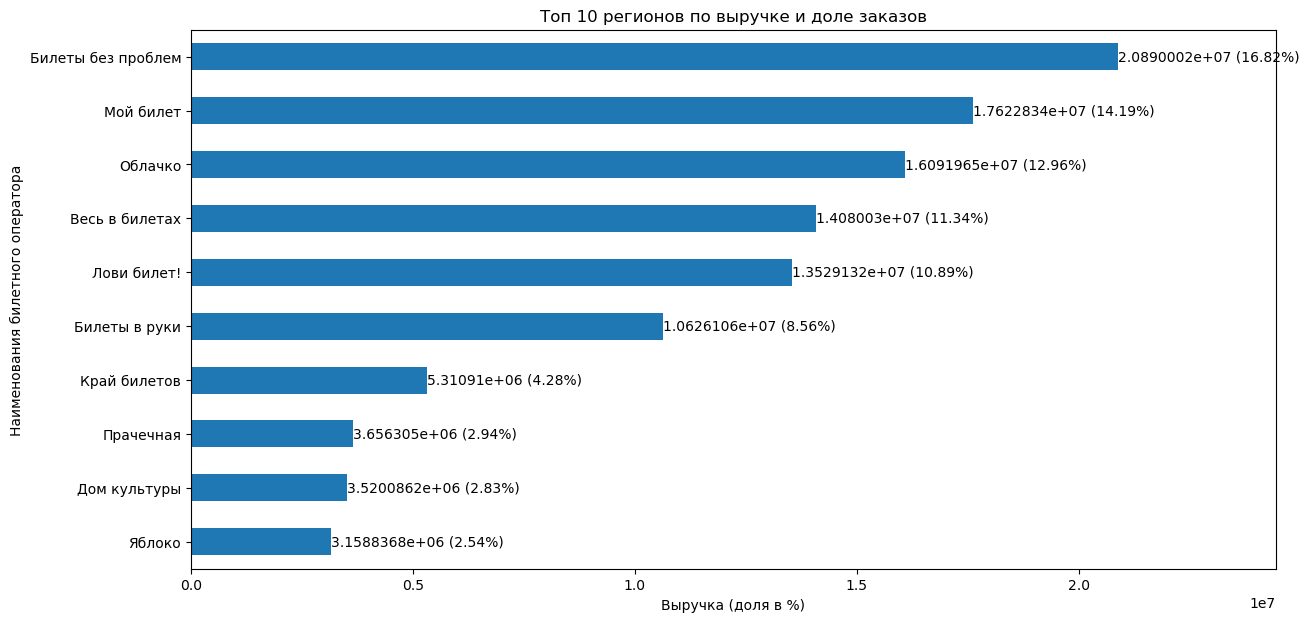

In [39]:
# Групируем уникальные мерроприятия по региону
group_region = df.groupby('service_name').agg(
    count_event = ('unique_event_id', 'nunique'),
    count_orders = ('order_id','count'),
    sum_revenue = ('revenue_rub', 'sum')
)


# Строим график столбчатой диаграммы - Топ 10 билетных операторов по количеству и доле проведения уникальных мероприятий
plot_top10_bar(
    df = group_region,
    column = 'count_event',
    title= 'Топ 10 билетных операторов по количеству и доле проведения уникальных мероприятий',
    x_label='Количество мероприятий (доля в %)',
    y_label='Наименования билетного оператора'
)

# Строим график столбчатой диаграммы - Топ 10 регионов по количеству и доле заказов
plot_top10_bar(
    df = group_region,
    column = 'count_orders',
    title='Топ 10 регионов по количеству и доле заказов',
    x_label='Количество заказов (доля в %)',
    y_label='Наименования билетного оператора'
)

# Строим график столбчатой диаграммы - Топ 10 регионов по количеству и доле заказов
plot_top10_bar(
    df = group_region,
    column = 'sum_revenue',
    title='Топ 10 регионов по выручке и доле заказов',
    x_label='Выручка (доля в %)',
    y_label='Наименования билетного оператора'
)

</font><font color='Blue'><b> В топ 10 билетных операторов наблюдается более плавное понижение, лидирующую позицию не занимает ни один оператор, но выделить можно "Билеты без проблем" который является лидером по заказам и выручке, а в топе уникальных мероприятий занимает 2 место.</b></font><br>


<a id='intro432'></a>
#### [Промежуточные выводы](#intro)

</font><font color='Blue'><b> По результатам анализа распределения событий по регионам и партнерам можно сделать вывод, что топ регионов имеет тенденцию большого отставания от лидеров, в топе операторов снижение более плавное.
    
Стоит расмотреть привлечение билетных операторов в регионах с малым разнообразий мероприятий и стремиться к увеличению количества заказов, выручки. </b></font><br>


<a id='intro5'></a>
## [Статистический анализ данных](#intro)

### [Подготовка к тесту](#intro)

Для проверки поступило две гипотезы, которые предполагают большую активность пользователей мобильных устройств:
* Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
* Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

Для проверки гипотез необходимо:
* выбрать данные только за осень и разделить пользователей на группы,
* проверить отсутствие пересечений групп по пользователю,
* группируем по пользователям и расчитываем метрики,
* проверить равномерность распределения пользователей по группам теста,
* выбор теста.


In [40]:
# Разделяем пользователей на группы
group_mobile = df[(df['device_type_canonical'] == 'mobile')&(df['season'] == 'осень')]
group_desktop = df[(df['device_type_canonical'] == 'desktop')&(df['season'] == 'осень')]

a = group_mobile['user_id'].nunique()
b = group_desktop['user_id'].nunique()

# Осуществляем сопоставление пользователей в Группах А и В, осуществляем вывод количества пересекающихся пользователей 
intersection = len(set(group_mobile['user_id']) & set(group_desktop['user_id']))
print(f"Количество пересекающихся пользователей в группе А (mobile) и группе В (desktop) составляет: {intersection}")
print(f"Количество данных в группе А (mobile): {a} и группе В (desktop) составляет: {b}")

Количество пересекающихся пользователей в группе А (mobile) и группе В (desktop) составляет: 3210
Количество данных в группе А (mobile): 14162 и группе В (desktop) составляет: 4842


 Мы можем наблюдать большое пересечение пользователей. Есть два варианта отбросить пересекающихся пользователей или учесть в проверке гипотез пользователей, которые используют и мобильные, и стационарные устройства. Проверим каждый вариант. 

<a id='intro52'></a>
### [ТЕСТ 1. Проверка гипотез с предворительным удалением пересекающихся пользователей](#intro)


В группах пересекаются пользователи, для соблюдения не пересечения удаляем их. 

In [41]:
# Удаляем пересечения в group_a_mobile
mobile = group_mobile[~group_mobile['user_id'].isin(group_desktop['user_id'])]

# Удаляем пересечения в group_b_desktop
desktop = group_desktop[~group_desktop['user_id'].isin(group_mobile['user_id'])]

a = mobile['user_id'].nunique()
b = desktop['user_id'].nunique()

print(f"Количество оставшихся данных в группе А (mobile): {a} и группе В (desktop) составляет: {b}")

Количество оставшихся данных в группе А (mobile): 10952 и группе В (desktop) составляет: 1632


In [42]:
# Групируем данные по пользователям и расчитываем метрики
group_a_mobile = mobile.groupby('user_id').agg(
    count_orders = ('order_id', 'count'),
    avg_days_since_prev = ('days_since_prev_new', 'mean')
)

group_b_desktop = desktop.groupby('user_id').agg(
    count_orders = ('order_id', 'count'),
    avg_days_since_prev = ('days_since_prev_new', 'mean')
)

# Формируем переменные с группами
# Гипотеза 1
mobile_count_orders = group_a_mobile['count_orders']
desktop_count_orders = group_b_desktop['count_orders']

# Гипотеза 2: убираем пустые значения
mobile_avg_days_since_prev = group_a_mobile[~group_a_mobile['avg_days_since_prev'].isna()]['avg_days_since_prev']
desktop_avg_days_since_prev = group_b_desktop[~group_b_desktop['avg_days_since_prev'].isna()]['avg_days_since_prev']

**Гипотеза 1: Среднее количество заказов на одного пользователя мобильного приложения выше по**

**сравнению с пользователями стационарных устройств.**

Количество заказов в группе A (mobile): 10952
Количество заказов в группе B (desktop): 1632
Процентная разница: 85.10%


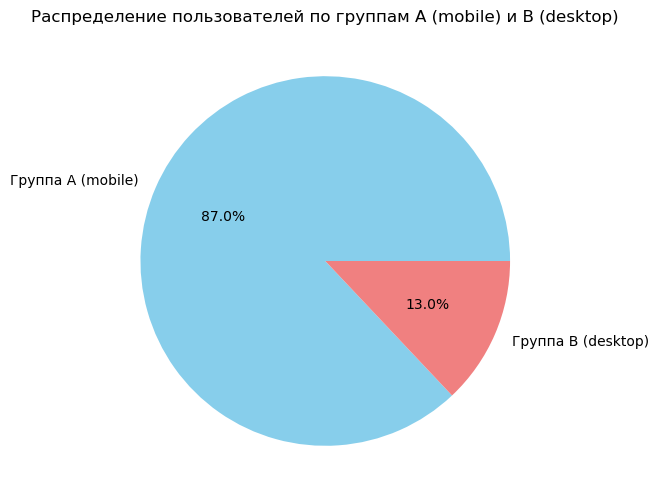

**Гипотеза 2: Среднее время между заказами пользователей мобильных приложений выше по сравнению с**

**пользователями стационарных устройств.**

Количество заказов в группе A (mobile): 6788
Количество заказов в группе B (desktop): 856
Процентная разница: 87.39%


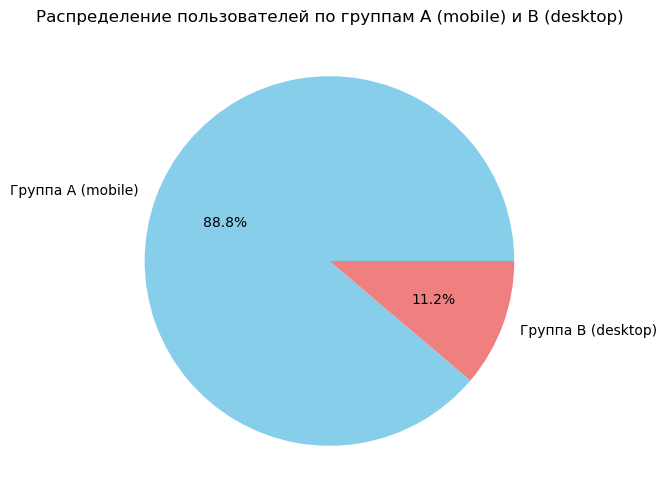

In [43]:
a_t1 = len(mobile_count_orders)
b_t1 = len(desktop_count_orders)

# Осуществляем расчёт процентной разницы
p = 100 * (abs(a_t1 - b_t1) / a_t1)

# Выводим результаты на экран
display(Markdown('**Гипотеза 1: Среднее количество заказов на одного пользователя мобильного приложения выше по**'))
display(Markdown('**сравнению с пользователями стационарных устройств.**'))
print(f"Количество заказов в группе A (mobile): {a_t1}")
print(f"Количество заказов в группе B (desktop): {b_t1}")
print(f"Процентная разница: {p:.2f}%")

# Данные для визуализации
t1 = [a_t1, b_t1]
groups = ['Группа A (mobile)', 'Группа B (desktop)']

# Строим график
plt.figure(figsize=(8, 6))
plt.pie(t1, labels=groups, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])

plt.title('Распределение пользователей по группам A (mobile) и B (desktop)')

plt.show()

# ----------------------------------------------------------------------------------------------------------------------

a_t2 = len(mobile_avg_days_since_prev)
b_t2 = len(desktop_avg_days_since_prev)

# Осуществляем расчёта процентной разницы
p = 100 * (abs(a_t2 - b_t2) / a_t2)

# Выводим результаты на экран
display(Markdown('**Гипотеза 2: Среднее время между заказами пользователей мобильных приложений выше по сравнению с**'))
display(Markdown('**пользователями стационарных устройств.**'))
print(f"Количество заказов в группе A (mobile): {a_t2}")
print(f"Количество заказов в группе B (desktop): {b_t2}")
print(f"Процентная разница: {p:.2f}%")

# Данные для визуализации
t2 = [a_t2, b_t2]
groups = ['Группа A (mobile)', 'Группа B (desktop)']

# Строим график
plt.figure(figsize=(8, 6))
plt.pie(t2, labels=groups, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])

plt.title('Распределение пользователей по группам A (mobile) и B (desktop)')

plt.show()

Разница между группами в 7 раз. Неравномерность групп создает риск смещения оценки дисперсии и может исказить p-значение (вероятность ошибки) при стандартных тестах.

In [44]:
# Тест на равенство дисперсий (тест Левена)
_, p_levene = st.levene(mobile_count_orders, desktop_count_orders)
print(f"\nТЕСТ ЛЕВЕНА НА РАВЕНСТВО ДИСПЕРСИЙ ДЛЯ СРЕДНЕГО КОЛИЧЕСТВА ЗАКАЗОВ:")
print(f"p-value = {p_levene:.4f} {'(дисперсии статистически не отличаются)' if p_levene > 0.05 else '(дисперсии не равны)'}")


# Тест на равенство дисперсий (тест Левена)
_, p_levene = st.levene(mobile_avg_days_since_prev, desktop_avg_days_since_prev)
print(f"\nТЕСТ ЛЕВЕНА НА РАВЕНСТВО ДИСПЕРСИЙ ДЛЯ СРЕДНЕГО ВРЕМЕНИ МЕЖДУ ЗАКАЗАМИ:")
print(f"p-value = {p_levene:.4f} {'(дисперсии статистически не отличаются)' if p_levene > 0.05 else '(дисперсии не равны)'}")



ТЕСТ ЛЕВЕНА НА РАВЕНСТВО ДИСПЕРСИЙ ДЛЯ СРЕДНЕГО КОЛИЧЕСТВА ЗАКАЗОВ:
p-value = 0.0000 (дисперсии не равны)

ТЕСТ ЛЕВЕНА НА РАВЕНСТВО ДИСПЕРСИЙ ДЛЯ СРЕДНЕГО ВРЕМЕНИ МЕЖДУ ЗАКАЗАМИ:
p-value = 0.0000 (дисперсии не равны)


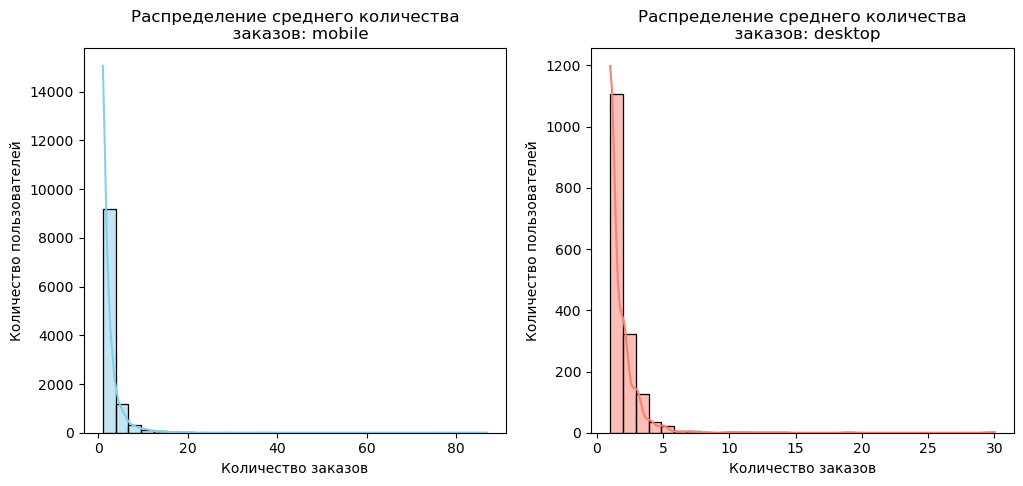

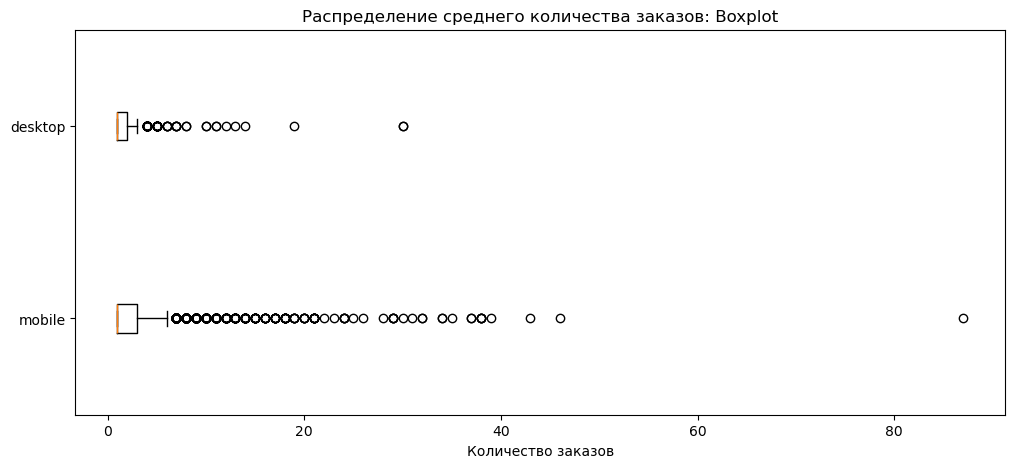

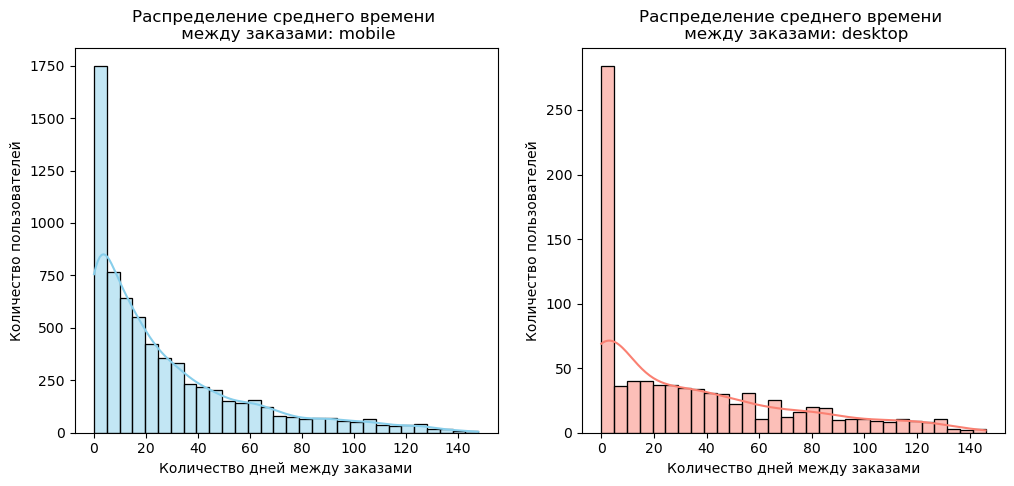

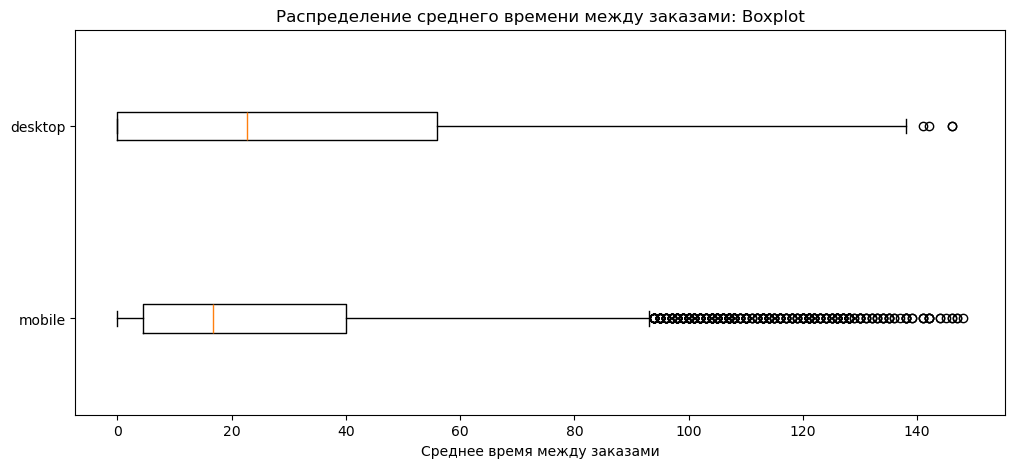

In [45]:
# Гипотеза 1
# Визуализация распределения для выборок 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(mobile_count_orders, kde=True, bins = 30, color='skyblue', label='СПб')
plt.title('Распределение среднего количества\n  заказов: mobile')
plt.ylabel('Количество пользователей')
plt.xlabel('Количество заказов')

plt.subplot(1, 2, 2)
sns.histplot(desktop_count_orders, kde=True, bins = 30, color='salmon', label='Москва')
plt.title('Распределение среднего количества\n  заказов: desktop')
plt.ylabel('Количество пользователей')
plt.xlabel('Количество заказов')

plt.show()

# Визуализация boxplot
plt.figure(figsize=(12, 5))
plt.boxplot([mobile_count_orders, desktop_count_orders], vert = False)

# Настройка подписей
plt.title('Распределение среднего количества заказов: Boxplot')
plt.xlabel('Количество заказов')  # Подпись оси X
plt.yticks([1, 2], ['mobile', 'desktop'])  # Метки на оси Y

plt.show()


# Гипотеза 2
# Визуализация распределения для выборок 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(mobile_avg_days_since_prev, kde=True, bins = 30, color='skyblue')
plt.title('Распределение среднего времени \n между заказами: mobile')
plt.ylabel('Количество пользователей')
plt.xlabel('Количество дней между заказами')

plt.subplot(1, 2, 2)
sns.histplot(desktop_avg_days_since_prev, kde=True, bins = 30, color='salmon')
plt.title('Распределение среднего времени \n между заказами: desktop')
plt.ylabel('Количество пользователей')
plt.xlabel('Количество дней между заказами')

plt.show()


# Визуализация boxplot
plt.figure(figsize=(12, 5))
plt.boxplot([mobile_avg_days_since_prev, desktop_avg_days_since_prev], vert = False)

# Настройка подписей
plt.title('Распределение среднего времени между заказами: Boxplot')
plt.xlabel('Среднее время между заказами')  # Подпись оси X
plt.yticks([1, 2], ['mobile', 'desktop'])  # Метки на оси Y

plt.show()

Можно наблюдать, что выборки `не равны по объему`, также согласно тесту Левина `дисперсии не равны`.
В выборках наблюдаем, что распределение асимметричное (ярко выражена правосторонняя асимметрия). Также есть большое количество выбросов, в выборке о среднем времени между заказами (mobile) выбросов намного больше, чем в остальных выборках. 
Т.к размеры выборок довольно большие:
* для проверки Гипотезы с средним количеством заказов: в группе A (mobile): 10955, в группе B (desktop): 1631, 
* для проверки Гипотезы с средним временем между заказами: в группе A (mobile): 6810, в группе B (desktop): 858, 

можно воспользоваться ЦПТ: «Согласно Центральной предельной теореме, при таких объёмах выборок распределение выборочных средних стремится к нормальному, даже если исходные данные сильно асимметричны» и использовать   `t-тест Уэлча`.  **Но по результатам проверки оптимальным вариантом выбора теста будет непараметрический тест: ` тест Манна-Уитни`, который подходит для работы малых выборках и несоблюдении условий нормальности, с неравными дисперсиями и размерами для проверки обоих Гипотез. Кроме того, т.к. проверяется 2 гипотизы, а всего 9 тестов, то необходимо воспользоваться поправкой Бонферрони** 

<a id='intro53'></a>
### [Проведение тестов](#intro)

**Первая гипотеза** 

**Нулевая гипотеза(Н0):** "Среднее количество заказов на одного пользователя мобильного приложения равно или меньше среднего количества заказов на пользователя стационарных устройств."

 H₀: pA ≤ pB 
 
**Альтернативная гипотеза(Н1):** "Среднее количество заказов на одного пользователя мобильного приложения больше, чем у пользователей стационарных устройств."

 H₁: pA > pB 

In [46]:
# Уровень статистической значимости 0.05
# Используем формулу Бонферрони alpha_korr = alpha/n
alpha_korr = 0.05/9

# применяем тест Манна-Уитни
mw_ttest, p_value = mannwhitneyu(
    mobile_count_orders, 
    desktop_count_orders,
    alternative='greater' # mu_mobile > mu_desktop
) 

if p_value > alpha_korr:
    print(f'pvalue={p_value} > {alpha_korr}')
    print('Не удалось отвергнуть нулевую гипотезу!')
    print('Среднее количество заказов на одного пользователя мобильного приложения равно или меньше среднего количества')
    print('заказов на пользователя стационарных устройств.')

else:
    print(f'pvalue={p_value} < {alpha_korr}')
    print('Нулевая гипотеза не находит подтверждения!')
    print('Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями') 
    print('стационарных устройств.')

pvalue=3.4019774702334553e-43 < 0.005555555555555556
Нулевая гипотеза не находит подтверждения!
Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями
стационарных устройств.


**Вторая гипотеза** 

**Нулевая гипотеза(Н0):** "Среднее время между заказами пользователей мобильных приложений равно или меньше среднего времени между заказами у пользователей стационарных устройств."

 H₀: pA ≥ pB 
 
**Альтернативная гипотеза(Н1):** "Среднее время между заказами пользователей мобильных приложений больше, чем у пользователей стационарных устройств."

 H₁: pA > pB 

In [47]:
# Уровень статистической значимости 0.05
# Используем формулу Бонферрони alpha_korr = alpha/n
alpha_korr = 0.05/9

# применяем тест Манна-Уитни
mw_ttest, p_value = mannwhitneyu(
    mobile_avg_days_since_prev,  
    desktop_avg_days_since_prev,
    alternative='greater' # mu_mobile > mu_desktop
) 

if p_value > alpha_korr:
    print(f'pvalue={p_value} > {alpha_korr}')
    print('Не удалось отвергнуть нулевую гипотезу!')
    print('Среднее время между заказами пользователей мобильных приложений равно или меньше среднего времени между') 
    print('заказами у пользователей стационарных устройств.')

else:
    print(f'pvalue={p_value} < {alpha_korr}')
    print('Нулевая гипотеза не находит подтверждения!')
    print('Среднее время между заказами пользователей мобильных приложений больше, чем у пользователей стационарных') 
    print('устройств.')

pvalue=0.9825487290704554 > 0.005555555555555556
Не удалось отвергнуть нулевую гипотезу!
Среднее время между заказами пользователей мобильных приложений равно или меньше среднего времени между
заказами у пользователей стационарных устройств.


По результатам проверки гипотиз:
   * Отвергли нулевую гипотезу и подтвердили, что "Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств" 
   * Подтвердили нулевую гипотезу, pvalue=0.9825487290704554 является очень высоким значением, можно сказать что данные полностью согласуются с нулевой гипотезой. "Среднее время между заказами пользователей мобильного приложения и стационарных устройств не отличаются."

<a id='intro54'></a>
### [ТЕСТ 2. Проверка гипотез  с оставлением пересекающихся пользователей](#intro)

Ранее на анализ было представлено 2 гипотезы, которые при оставлении пересекающихся пользователей стоит уточнить и провести новое тестирование.

#### [Проверка Гипотезы 1](#intro)


1) `Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.`

Для проведения теста, где мы не отбрасываем пользователей, которые состоят и в группе покупки с мобильных устройств, и в группе покупки со стационарных устройств, то следует уточнить гипотезу: `Необходимо определить, существует ли статистически значимое различие в количестве заказов, совершаемых с мобильных и стационарных (десктопных) устройств, наблюдается ли выше перекос распределения в сторону мобильных устройств`. Для этого нам нужно для каждого клиента определить, сколько он совершил заказов с одного и сколько с другого устройства, учитываем и нулевые показатели. Чтобы оценить значимость перекоса, проверим равна ли нулю (или не больше / не меньше 0) средняя разность в количестве заказов между мобильными и стационарными устройствами.

In [48]:
# Группируем данные 
pivot = df.pivot_table(
    index='user_id',
    columns='device_type_canonical',
    values='order_id',
    aggfunc='count',
    fill_value=0
)

# создаем новый столбец с разницей между устройствами для проверки распределения
pivot['difference'] =  pivot['mobile'] - pivot['desktop'] 


Распределение данных в столбце difference


count    21817.000000
mean         6.697850
std         61.103699
min       -542.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       4601.000000
Name: difference, dtype: float64

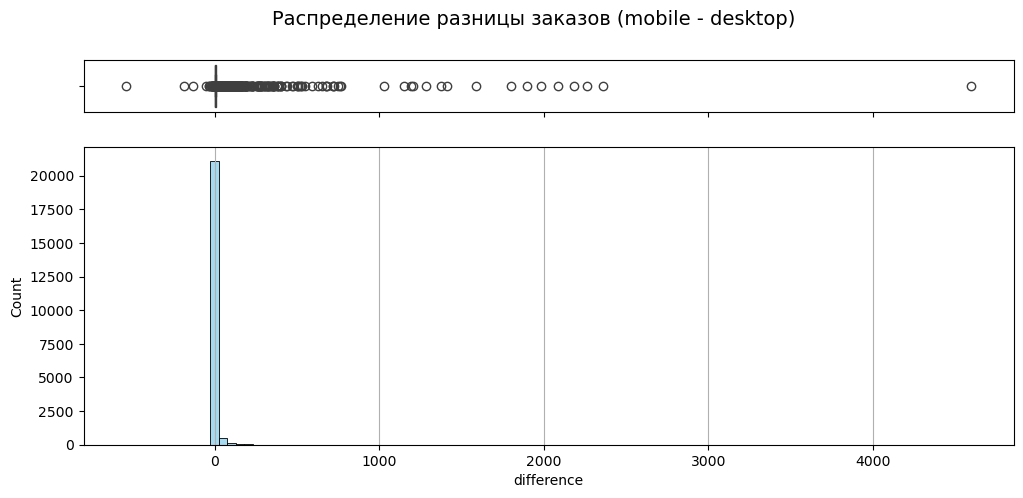

In [49]:
print(f"Распределение данных в столбце difference")
display(pivot['difference'].describe())

# Гипотеза 1
# Создаём фигуру: boxplot сверху (компактный), histplot снизу (подробный)
f, (ax_box, ax_hist) = plt.subplots(
    2,
    sharex=True,
    figsize=(12, 5),
    gridspec_kw={"height_ratios": (0.15, 0.85)}  # 15% / 85%
)

# Строим графики в логичном порядке
sns.boxplot(
    data=pivot,
    x='difference',
    orient="h",
    ax=ax_box
)  # boxplot сверху, компактный

sns.histplot(
    data=pivot,
    x='difference',
    bins = 100, color='skyblue',
    ax=ax_hist
)  # histplot снизу, подробный

# Убираем подпись оси X у boxplot (она дублируется в histplot)
ax_box.set(xlabel='')

# Дополнительно: можно добавить заголовок
plt.suptitle('Распределение разницы заказов (mobile - desktop)', fontsize=14)
plt.grid(axis='x')

plt.show()

При проверке распределения разности можем наблюдать правостороннюю ассиметрию, с большим количеством выбросов и длинным хвостом, в таком случае для проверки гипотезы необходимо использовать  параметрический критерий `Вилкоксона`.

**Далее сформируем нулевую и альтернативную гипотезы и проведем тест.**

**Нулевая гипотеза(Н0):** "Средняя разность в количестве заказов между мобильными и десктопными устройствами равна нулю или меньше."

 H₀: Med(mobile−desktop) ≤ 0
 
**Альтернативная гипотеза(Н1):** "Средняя разность в количестве заказов на одного пользователя мобильного приложения больше, чем у пользователей стационарных устройств."

 H₁: Med(mobile−desktop)>0

In [50]:
# Уровень статистической значимости 0.05
# Используем формулу Бонферрони alpha_korr = alpha/n
alpha_korr = 0.05/9

# применяем Вилкоксона для парных выборок (односторонний, в пользу мобильных)
stat, p_value = st.wilcoxon(
    pivot['mobile'],  
    pivot['desktop'],
    alternative='greater' # mu_mobile > mu_desktop
) 

if p_value > alpha_korr:
    print(f'pvalue={p_value} > {alpha_korr}')
    print('Не удалось отвергнуть нулевую гипотезу!')
    print('Средняя разность в количестве заказов между мобильными и десктопными устройствами равна нулю или меньше') 

else:
    print(f'pvalue={p_value} < {alpha_korr}')
    print('Нулевая гипотеза не находит подтверждения!')
    print('Средняя разность в количестве заказов на одного пользователя мобильного приложения больше, чем у пользователей') 
    print('стационарных устройств.')

pvalue=0.0 < 0.005555555555555556
Нулевая гипотеза не находит подтверждения!
Средняя разность в количестве заказов на одного пользователя мобильного приложения больше, чем у пользователей
стационарных устройств.


Первая гипотеза не находит подтверждения. При смене подхода к тесту нулевая гипотеза так же не нашла подтверждения и "Средняя разность в количестве заказов на одного пользователя мобильного приложения больше, чем у пользователей
стационарных устройств."

<a id='intro542'></a>
#### [Проверка Гипотезы 2](#intro)

2) "Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств."

Для проверки второй гипотезы мы также отказались от исключения пересекающихся пользователей. 
Т.к. есть пользователи, которые пользовались и мобильным устройством и стационарным, то целесообразно проверить среднее время между группами, когда пользователь переходил с одного устройства на другое или оставался на одном устройстве.
Всего таких групп 6:
 * mobile_mobile vs desktop_mobile
 * mobile_mobile vs mobile_desktop
 * mobile_mobile vs desktop_desktop
 * desktop_mobile vs mobile_desktop
 * desktop_mobile vs desktop_desktop
 * mobile_desktop vs desktop_desktop

измененная гипотеза теперь имеет следующую формулировку: `"Между разными сценариями использования устройств (mobile → mobile, desktop → mobile, mobile → desktop, desktop → desktop) существуют статистически значимые различия в среднем времени между заказами пользователей."`

Для проверки вновь сформированной гипотезы необходимо добавить информацию предыдущего устройства, информация о разнице между заказами уже была расчитана(столбец days_since_prev_new), а далее сформируем группы, оставив только те, где был предыдущий заказ.

Распределение интервалов по группам переходов:


,count,mean,std,min,25%,50%,75%,95%,99%,max
transition_group,,,,,,,,,,
desktop_desktop,17853.0,2.352098,10.293385,0.0,0.0,0.0,0.0,13.0,55.0,146.0
desktop_mobile,22604.0,4.422182,13.435326,0.0,0.0,0.0,2.0,26.0,74.0,147.0
mobile_desktop,22599.0,4.394531,13.147997,0.0,0.0,0.0,2.0,26.0,73.0,145.0
mobile_mobile,149662.0,3.788256,12.477631,0.0,0.0,0.0,1.0,22.0,69.0,148.0


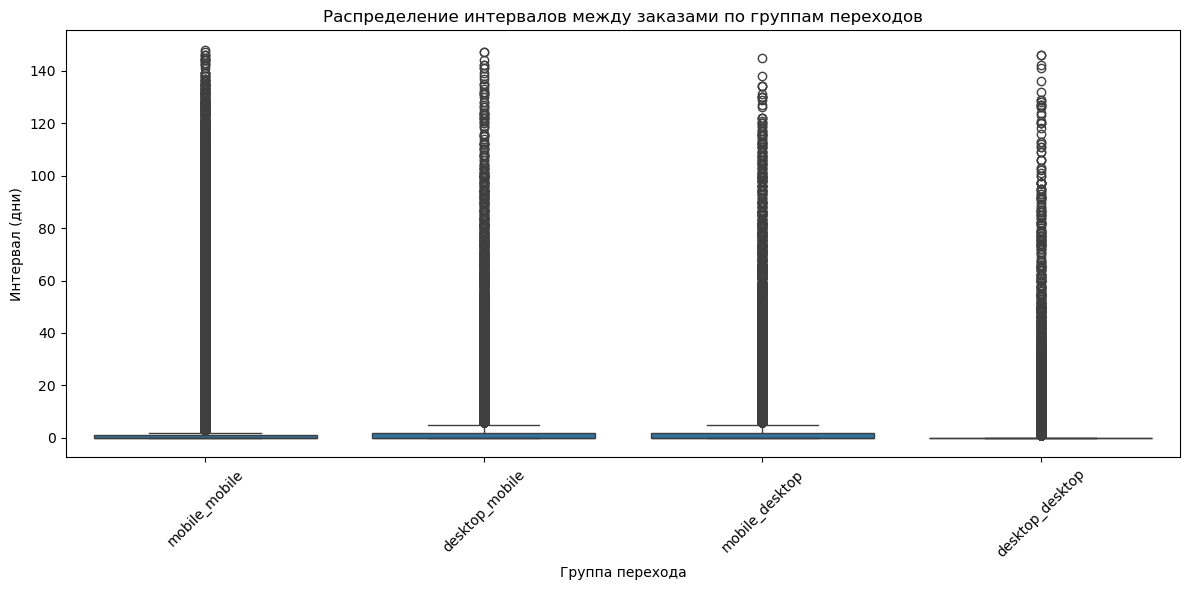

In [51]:
# Исходные данные
data = df[['user_id', 'created_ts_msk', 'device_type_canonical', 'days_since_prev_new']].copy()


# Сортируем по пользователю и дате
data = data.sort_values(by=['user_id', 'created_ts_msk'])

# Добавляем предыдущее устройство
data['prev_device'] = data.groupby('user_id')['device_type_canonical'].shift(1)

# Формируем группу перехода
data['transition_group'] = data['prev_device'] + '_' + data['device_type_canonical']

# Оставляем только строки с переходами (где есть предыдущий заказ)
transitions = data[data['prev_device'].notna()].copy()

print("Распределение интервалов по группам переходов:")
display(transitions.groupby('transition_group')['days_since_prev_new'].describe(percentiles = [0.25, 0.5, 0.75, 0.95, 0.99]))


# Визуализация boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=transitions, x='transition_group', y='days_since_prev_new')

# Настройка подписей
plt.title('Распределение интервалов между заказами по группам переходов')
plt.ylabel('Интервал (дни)')
plt.xlabel('Группа перехода')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Выше из таблицы с информацией по группам и графика boxplot мы можем судить о больших выбросах и правостороннем хвосте, для проверки гипотез нам потребуется воспользоваться непараметрическим тестом Манна-Уитни.

**Далее сформируем нулевую и альтернативную гипотезы и проведем тест.**

**Нулевая гипотеза(Н0):** "Медианы интервалов между заказами в двух сравниваемых группах не различаются."

 H₀: Med(group1) = Med(group2)
 
**Альтернативная гипотеза(Н1):** "Медианы интервалов между заказами в двух группах статистически значимо различаются (без указания направления)."

 H₁: Med(group1) ≠ Med(group2)

In [52]:
# Извлекаем данные по группам
groups = {}
for group in transitions['transition_group'].unique():
    groups[group] = transitions[transitions['transition_group'] == group]['days_since_prev_new'].dropna()

# Все возможные пары групп
pairs = list(combinations(groups.keys(), 2))

display(Markdown('**Результаты попарных сравнений:**'))

print("-" * 50)

alpha = 0.05
correction_alpha = alpha / (len(pairs) + 3)  # коррекция Бонферрони
results = []

for group1, group2 in pairs:
    # Тест Манна‑Уитни (двусторонний)
    stat, p_value = st.mannwhitneyu(
        groups[group1], groups[group2], alternative='two-sided'
    )

    mean1, mean2 = groups[group1].mean(), groups[group2].mean()
    significant = p_value < correction_alpha

    results.append({
        'Group1': group1,
        'Mean1': round(mean1, 2),
        'Group2': group2,
        'Mean2': round(mean2, 2),
        'p-value': round(p_value, 4),
        'Significant': significant
    })

    
    display(Markdown(f'**{group1} vs {group2}:**'))
    print(f"  H₀: Med({group1}) = Med({group2})")
    print(f"  H₁: Med({group1}) ≠ Med({group2})")
    print(f"  Среднее {group1}: {mean1:.2f} дней")
    print(f"  Среднее {group2}: {mean2:.2f} дней")
    if significant:
        print(f'  pvalue={p_value} < {correction_alpha:.4f}')
        print(f"  Нулевая гипотеза не находит подтверждения!")
        print("  Медианы интервалов между заказами в двух группах статистически значимо различаются.")
        if mean1 > mean2:
            print(f"  Интервалы в группе {group1} значимо длиннее")
        else:
            print(f"  Интервалы в группе {group2} значимо длиннее")
    else:
        print(f'  pvalue={p_value} ≥ {correction_alpha:.4f}')
        print(f"  Не удалось отвергнуть нулевую гипотезу!")
        print("  Медианы интервалов между заказами в двух сравниваемых группах не различаются.")
    print()

**Результаты попарных сравнений:**

--------------------------------------------------


**mobile_mobile vs desktop_mobile:**

  H₀: Med(mobile_mobile) = Med(desktop_mobile)
  H₁: Med(mobile_mobile) ≠ Med(desktop_mobile)
  Среднее mobile_mobile: 3.79 дней
  Среднее desktop_mobile: 4.42 дней
  pvalue=4.264420744969966e-70 < 0.0056
  Нулевая гипотеза не находит подтверждения!
  Медианы интервалов между заказами в двух группах статистически значимо различаются.
  Интервалы в группе desktop_mobile значимо длиннее



**mobile_mobile vs mobile_desktop:**

...

  H₀: Med(desktop_mobile) = Med(mobile_desktop)
  H₁: Med(desktop_mobile) ≠ Med(mobile_desktop)
  Среднее desktop_mobile: 4.42 дней
  Среднее mobile_desktop: 4.39 дней
  pvalue=0.9301969149032425 ≥ 0.0056
  Не удалось отвергнуть нулевую гипотезу!
  Медианы интервалов между заказами в двух сравниваемых группах не различаются.



**desktop_mobile vs desktop_desktop:**

  H₀: Med(desktop_mobile) = Med(desktop_desktop)
  H₁: Med(desktop_mobile) ≠ Med(desktop_desktop)
  Среднее desktop_mobile: 4.42 дней
  Среднее desktop_desktop: 2.35 дней
  pvalue=0.0 < 0.0056
  Нулевая гипотеза не находит подтверждения!
  Медианы интервалов между заказами в двух группах статистически значимо различаются.
  Интервалы в группе desktop_mobile значимо длиннее



**mobile_desktop vs desktop_desktop:**

  H₀: Med(mobile_desktop) = Med(desktop_desktop)
  H₁: Med(mobile_desktop) ≠ Med(desktop_desktop)
  Среднее mobile_desktop: 4.39 дней
  Среднее desktop_desktop: 2.35 дней
  pvalue=0.0 < 0.0056
  Нулевая гипотеза не находит подтверждения!
  Медианы интервалов между заказами в двух группах статистически значимо различаются.
  Интервалы в группе mobile_desktop значимо длиннее



Тест показал, почти все группы имеют статистические различия, только группы desktop_mobile vs mobile_desktop не различаются.

* Группа desktop_desktop показала самый короткий интервал (2,35 дня), пользователи наиболее лояльны, когда остаются на десктопе.

* Группа mobile_mobile показала средний интервал (3,79 дня), лояльность выше, чем при смене устройств, но ниже, чем у desktop_desktop.

* Группы со сменой устройств (desktop_mobile и mobile_desktop) имеет самые длинные интервалы (4,42 и 4,39 дня соответственно), смена устройства увеличивает время до следующего заказа на ~2 дня по сравнению с desktop_desktop. При этом стоит отметить, что нет разницы между типами смены (desktop ↔ mobile).

<a id='intro6'></a>
## [Общие выводы и рекомендации](#intro)

По результатам анализа данных, предоставленных Яндекс Афиша за июнь – октябрь 2024г. было выявлено:
 * Наблюдается рост выручки, при этом с приходом осени рост значительно вырос. Осенью количество заказов в сентябре составило 56 тысяч, а в октябре 78 тысяч заказов. 
 * Пользователи в том же процентном соотношении продолжили пользоваться мобильными и стационарными устройствами. 
 * Касаемо типа мероприятий и возрастного рейтинга, то в некоторых сегментах произошли изменения, пользователи стали больше ходить на другие мероприятия, с иным возрастным рейтингом, чем в летнее время, в результате чего мы можем видеть изменения в топе. Абсолютным лидером по оформлению заказов остались "Концерты", но осенью пользователи стали предпочитать заказывать билеты и на другие мероприятия, спрос снизился на 5%, как и на ряд других ранее популярных мероприятий, а на "Театр", "Спорт" и "Ёлки" увеличился. Произошли изменения между летним и осенним периодом относительно рейтинга 16+ и 18+, покупки билетов на данные мероприятия снизились.
 * Изменения описанные выше затронули среднюю выручку с билета, в результате у некоторых типов мероприятий стало наблюдаться больше средняя выручка, а у других существенно меньшая. При этом уменьшение средней выручки на лидирующих мероприятиях, таких как Театр и Концерты, на 17% и 27% выглядят существенным уменьшением, по сравнению с увеличением на малопопулярные мероприятия, такие как стендап, выставки, спорт. 
 * Пользовательская активность в осенний период в динамике количества заказов и количества активных пользователей DAU имеет колебательный рост. Динамика среднего числа заказов на одного пользователя не показала большого прироста. В то же время средняя выручка сопровождается не большим ростом и многократными падениями, к концу рассматриваемого периода наблюдается падение средней выручки при росте заказов и количества активных пользователей. В данный период были выявлены две даты 03.09.2024г и 01.10.2024г, когда наблюдались большие возрастания количества заказов, но при этом падение средней выручки.
 * Пользователи ведут большую среднюю и типичную активность в будние дни, чем в выходные.  При этом средняя и типичная выручка в выходные дни наоборот увеличивается, но при общей тенденции на спад активности пользователей, то общаая выручка уменьшается.
 * По результатам анализа распределения событий по регионам (топ: "Каменевский регион" - 26%, "Североярская область" - 17%) и партнерам (топ * Лови билет ! - 20.01%, Билеты без проблем - 17.31%, Билеты в руки - 14.47%) можно сделать вывод, что в обоих топах есть свои лидеры, но в топе регионов распределение сопровождается большим отрывом двух лидеров, чем в топе партнеров. 

**В общем можно отметить рост выручки, который с сезонностью сменил направления.* 


    **Проверка гипотез:** На основании проведённых статистических тестов можно сформулировать следующие ключевые выводы о поведении пользователей в зависимости от типа устройства и сценариев его использования:

1. Количество заказов. Среднее количество заказов на одного пользователя выше для мобильного приложения по сравнению с пользователями стационарных устройств. Это может свидетельствовать о большей вовлечённости пользователей мобильных приложений либо о более удобном доступе к сервису с мобильных устройств.


2. Время между заказами. В целом среднее время между заказами у пользователей мобильных и стационарных устройств не отличается, то есть общая динамика повторных заказов сопоставима. Однако детальный анализ по сегментам выявил существенные различия.


3. Различия между сегментами пользователей. По результатам попарных сравнений медианы интервалов между заказами статистически значимо различаются почти во всех парах групп (во всех случаях, кроме сравнения desktop_mobile и mobile_desktop):

Наибольшая лояльность наблюдается в группе desktop_desktop (интервал между заказами — 2,35 дня). Пользователи, остающиеся на стационарном устройстве, делают заказы чаще всего. Вероятно, это связано с удобством работы на большом экране, наличием всех необходимых инструментов и отсутствием необходимости переключения контекста.

Средний уровень лояльности демонстрирует группа mobile_mobile (интервал — 3,79 дня). Лояльность выше, чем при смене устройств, но ниже, чем у desktop_desktop.

Наименьшая лояльность зафиксирована в группах со сменой устройств:

desktop_mobile: интервал — 4,42 дня;

mobile_desktop: интервал — 4,39 дня.

Разница в интервалах между этими группами статистически не значима, что говорит об отсутствии влияния направления смены устройства (с десктопа на мобильное и наоборот) на поведение пользователей.

4. Эффект смены устройства. Смена устройства приводит к увеличению времени до следующего заказа примерно на 2 дня по сравнению с группой desktop_desktop. Это может быть связано с:

потерей контекста при переходе между устройствами;

различиями в интерфейсе и функционале;

необходимостью повторной авторизации или настройки;

общим дискомфортом от смены привычной среды.</b></font><br>



Рекомендации:
   * Обратить внимание на значение "Другое", необходимо исключить возможность искажения данных данным значением, возможно стоит расширить выбор типа мероприятий, а данное собирательное значение убрать с площадки.
   * Проверить каким образом в данных образуются дубликаты и какова их природа, чтобы исключить искажение и завышение параметров.
   * Выяснить природу отрицательных значений в "revenue" и "total".
   * Выручка с Казахстана намного меньше, чем из Российской Федерации, стоит расмотреть привлечение больше партнеров в Казахстане.
   * Расширить привлечение организаторов мероприятий из регионов с небольшим количеством проводимых событий. Возможно, проведение акций для привлечения.
   * Обратить внимание на сезонность, с окончанием летнего периода обратить внимание на мероприятия с рейтингом до +16 и детскую аудиторию. Сделать упор на количество заказов, но с небольшой выручкой, при этом чтобы средний чек не снижался.
   * Проверить какие акции проводились в осенний период, могли ли они повлиять на снижение выручки на Концерты и Театры.
   * Делать больше упор на мобибильные приложения, но не бросать поддержку стационарных устройств.
   * Производить привлечение пользователей в выходные дни. Проверить нет ли недостатка в типов мероприятий в выходные.
   *  Рассмотреть способы увеличения активности пользователей в выходные дни и сохранить тенденцию увеличения средней выручки в выходные дни или избежать ее падения. Необходимо проверить какие мероприятия привлекают больше пользователей в буднии дни, проводятся ли они в выходные, а также наоборот какие мероприятия приносят большую прибыль в выходные и посящают ли их в течении будних дней.
   * Проверить различия интерфейса и функционала между устройствами.
    